# COMP8851 — CARE-GNN vs GHRN comparison

Combines the two models' separate result archives into the cross-model tables and
figures. Run it **after** both model notebooks.

It does not train anything. It reads finished evidence and reports it.

## Input

Either point it at two result directories on this machine, or upload the two zip
archives the model notebooks produced:

- `comp8851_care-gnn_results_*.zip`
- `comp8851_ghrn_results_*.zip`

Set the paths in the cell below.


In [32]:
import os, sys, subprocess, shutil, zipfile, json, time
from pathlib import Path

# ------------------------- POINT THESE AT YOUR RESULTS -------------------------
# Accepts a directory OR a .zip produced by a model notebook. Leave as None to
# auto-discover under the search roots below.
CARE_RESULTS = None     # e.g. "/kaggle/input/care-results/comp8851_care-gnn_results_....zip"
GHRN_RESULTS = None     # e.g. "/kaggle/working/comp8851/results_ghrn"
# -------------------------------------------------------------------------------

if Path("/kaggle").exists():
    BASE = Path("/kaggle/working/compare")
    SEARCH = [Path("/kaggle/input"), Path("/kaggle/working")]
elif Path("/content").exists():
    BASE = Path("/content/compare")
    SEARCH = [Path("/content")]
else:
    BASE = Path.cwd() / "compare"
    SEARCH = [Path.cwd()]

COMBINED = BASE / "results_combined"
COMBINED.mkdir(parents=True, exist_ok=True)
os.chdir(BASE)
print(f"Working in {BASE}")

def autodiscover(token):
    for root in SEARCH:
        if not root.exists():
            continue
        for pattern in (f"**/comp8851_{token}_results_*.zip", f"**/results_{token}"):
            for hit in sorted(root.glob(pattern)):
                return hit
    return None

def stage(source, label):
    """Copy a results directory or unzip an archive into the combined tree."""
    if source is None:
        source = autodiscover(label)
        if source is None:
            print(f"  {label}: NOT FOUND. Set the path manually at the top.")
            return False
        print(f"  {label}: auto-discovered {source}")
    source = Path(source)
    if not source.exists():
        print(f"  {label}: path does not exist: {source}")
        return False
    if source.suffix == ".zip":
        with zipfile.ZipFile(source) as z:
            z.extractall(COMBINED)
        print(f"  {label}: unpacked {source.name}")
    else:
        for item in source.iterdir():
            if item.name in ("reports", "plots"):
                continue        # per-model reports are regenerated below
            target = COMBINED / item.name
            if item.is_dir():
                shutil.copytree(item, target, dirs_exist_ok=True)
            else:
                shutil.copy2(item, target)
        print(f"  {label}: copied from {source}")
    return True

print("Staging results:")
ok_care = stage(CARE_RESULTS, "care-gnn")
ok_ghrn = stage(GHRN_RESULTS, "ghrn")

summaries = list(COMBINED.rglob("summary.json"))
print(f"\nFound {len(summaries)} run record(s) in the combined tree.")
if not summaries:
    print("Nothing to compare. Check the paths above.")


Working in /kaggle/working/compare
Staging results:
  care-gnn: auto-discovered /kaggle/working/comp8851/comp8851_care-gnn_results_20260913T042909Z.zip
  care-gnn: unpacked comp8851_care-gnn_results_20260913T042909Z.zip
  ghrn: NOT FOUND. Set the path manually at the top.

Found 3 run record(s) in the combined tree.


## Rebuild the shared code

The comparison needs the same evaluator and aggregator the runs used, so results are recomputed under identical rules.

In [33]:
for folder in ["shared", "shared/comp8851"]:
    (BASE / folder).mkdir(parents=True, exist_ok=True)
print('Directories ready.')


Directories ready.


In [34]:
%%writefile shared/__init__.py
"""Shared COMP8851 benchmark assets: split registry and the ``comp8851`` library."""


Writing shared/__init__.py


In [35]:
%%writefile shared/comp8851/__init__.py
"""COMP8851 shared benchmark library.

This package holds the machinery that must be *identical* across every model in
the COMP8851 fraud-GNN benchmark: dataset loading, split handling, evaluation,
timing, and the result-artefact schema required by master plan v4.4.

Model-specific code (architectures, losses, optimisers, hyperparameters) lives
under ``models/<model>/`` and must never be duplicated here.

Reference: COMP8851_VastAI_Master_Plan_FINAL_v4.4.docx, sections 4, 9 and 10.
"""

from . import artifacts, datasets, evaluator, protocol, runtime, splits

__all__ = ["artifacts", "datasets", "evaluator", "protocol", "runtime", "splits"]

__version__ = "1.0.0"


Writing shared/comp8851/__init__.py


In [36]:
%%writefile shared/comp8851/protocol.py
"""Protocol identity and constants for COMP8851 benchmark protocol v4.4.

Every controlled run must record which protocol it was executed under. The
constants here are the machine-readable form of the rules frozen in
``COMP8851_VastAI_Master_Plan_FINAL_v4.4.docx``.

Nothing in this module may be changed for a single model or dataset. A change
here is a protocol amendment and requires a dated entry in the decision
register plus a re-run of every affected comparison.
"""

from __future__ import annotations

import hashlib
import json
import subprocess
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import Any, Dict, Optional

# --------------------------------------------------------------------------
# Frozen protocol constants (master plan v4.4, sections 7.3, 8.1 and 10)
# --------------------------------------------------------------------------

PROTOCOL_VERSION = "vast-v4.4"

#: Split-generation seed. Fixed for every model and dataset; never varies.
SPLIT_SEED = 2

#: Training seeds for final unified runs (weight init, dropout, sampling).
TRAIN_SEEDS = (2, 42, 72)

#: Controlled training ratios. Validation and test IDs are identical across all
#: four; only the labelled training pool shrinks. TR10 < TR20 < TR30 < TR40.
TRAIN_RATIOS = {
    "TR40": 0.40,
    "TR30": 0.30,
    "TR20": 0.20,
    "TR10": 0.10,
}

#: Fixed validation and test fractions of the whole eligible node set.
VALIDATION_FRACTION = 0.20
TEST_FRACTION = 0.40

#: Unified stopping rule.
MAX_EPOCHS = 100
EARLY_STOPPING_PATIENCE = 20

#: Checkpoint selection metric under protocol v4.4. NOT AUROC -- the team
#: pre-registered validation AUPRC for the imbalanced fraud task.
SELECTION_METRIC = "auprc"

#: Threshold-selection rule: sweep validation thresholds 0.01..0.99 in 0.01
#: steps, maximise Macro-F1, tie-break by fraud recall then closeness to 0.5.
THRESHOLD_MIN = 0.01
THRESHOLD_MAX = 0.99
THRESHOLD_STEP = 0.01
THRESHOLD_OBJECTIVE = "macro_f1"

#: CPU thread cap applied identically on every benchmark machine.
CPU_THREAD_CAP = 8

#: The six datasets in scope. No substitutions, no additions.
DATASETS = ("yelpchi", "amazon", "tfinance", "tsocial", "elliptic", "fdcompcn")

#: Experimental tracks. These must never be merged in reporting.
TRACKS = ("author", "unified")

#: Compatibility statuses from master plan section 5.
COMPATIBILITY_STATUSES = (
    "PASS",
    "PASS_WITH_SHARED_ADAPTER",
    "CONDITIONAL",
    "FAILED_TECHNICAL",
    "NOT_ELIGIBLE",
)

#: Run status values used by the resumable run ledger.
RUN_STATUSES = ("PENDING", "RUNNING", "COMPLETE", "FAILED", "SKIPPED")

#: Datasets whose split is chronological rather than random-stratified.
CHRONOLOGICAL_DATASETS = ("elliptic",)


def sha256_file(path: Path | str, chunk_size: int = 1 << 20) -> str:
    """Return the SHA256 hex digest of a file."""
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(chunk_size), b""):
            digest.update(block)
    return digest.hexdigest()


def sha256_bytes(payload: bytes) -> str:
    """Return the SHA256 hex digest of a byte string."""
    return hashlib.sha256(payload).hexdigest()


def config_sha256(config: Dict[str, Any]) -> str:
    """Hash a fully-resolved configuration dictionary.

    The hash is computed after defaults and command-line overrides have been
    merged, so two runs sharing a ``config_sha256`` used byte-identical
    effective hyperparameters.
    """
    canonical = json.dumps(config, sort_keys=True, separators=(",", ":"), default=str)
    return sha256_bytes(canonical.encode("utf-8"))


def git_commit(repo_root: Optional[Path] = None) -> Optional[str]:
    """Return the current 40-character git commit SHA, or None if unavailable."""
    try:
        result = subprocess.run(
            ["git", "rev-parse", "HEAD"],
            cwd=str(repo_root) if repo_root else None,
            capture_output=True,
            text=True,
            timeout=10,
            check=False,
        )
    except (OSError, subprocess.SubprocessError):
        return None
    if result.returncode != 0:
        return None
    commit = result.stdout.strip()
    return commit if len(commit) == 40 else None


@dataclass
class ProtocolIdentity:
    """The identity fields required in every controlled run record.

    Master plan v4.4 section 9.6 makes each of these mandatory so that any two
    result rows can be checked for comparability without re-reading the code.
    """

    protocol_version: str = PROTOCOL_VERSION
    hardware_profile_id: Optional[str] = None
    container_digest: Optional[str] = None
    model_source_commit: Optional[str] = None
    dataset_manifest_version: Optional[str] = None
    source_sha256: Optional[str] = None
    dataset_view_id: Optional[str] = None
    view_sha256: Optional[str] = None
    split_registry_version: Optional[str] = None
    split_sha256: Optional[str] = None
    evaluator_commit: Optional[str] = None
    adapter_version: Optional[str] = None
    adapter_sha256: Optional[str] = None
    config_sha256: Optional[str] = None
    selection_metric: str = SELECTION_METRIC
    threshold_rule: str = (
        f"validation {THRESHOLD_OBJECTIVE} swept {THRESHOLD_MIN}-{THRESHOLD_MAX} "
        f"step {THRESHOLD_STEP}; tie-break fraud recall then closeness to 0.5"
    )
    max_epochs: int = MAX_EPOCHS
    early_stopping_patience: int = EARLY_STOPPING_PATIENCE
    split_seed: int = SPLIT_SEED
    notes: Dict[str, Any] = field(default_factory=dict)

    def to_dict(self) -> Dict[str, Any]:
        return asdict(self)

    def missing_fields(self) -> list[str]:
        """Return identity fields that are still unset.

        Used by the pre-run checklist: a final controlled run should not be
        reported while required provenance fields are empty.
        """
        required = [
            "hardware_profile_id",
            "model_source_commit",
            "source_sha256",
            "dataset_view_id",
            "split_sha256",
            "config_sha256",
        ]
        return [name for name in required if getattr(self, name) in (None, "")]


def run_name(model: str, dataset: str, track: str, ratio: str, seed: int,
             gpu: str, timestamp: str) -> str:
    """Build the canonical run name from master plan v4.4 section 9.2.

    Example: ``pcgnn_yelpchi_unified_tr40_seed2_a6000_20260912T093000Z``
    """
    safe_gpu = "".join(ch if ch.isalnum() else "-" for ch in gpu.lower()).strip("-")
    return (
        f"{model.lower()}_{dataset.lower()}_{track.lower()}_{ratio.lower()}"
        f"_seed{seed}_{safe_gpu}_{timestamp}"
    )


def result_dir(results_root: Path | str, model: str, dataset: str, track: str,
               ratio: str, seed: int) -> Path:
    """Return the required result directory from master plan v4.4 section 9.5.

    ``results/<model>/<dataset>/<track>/<ratio>/seed_<seed>/``
    """
    return (
        Path(results_root)
        / model.lower()
        / dataset.lower()
        / track.lower()
        / ratio.lower()
        / f"seed_{seed}"
    )


Writing shared/comp8851/protocol.py


In [37]:
%%writefile shared/comp8851/evaluator.py
"""Shared evaluator for the COMP8851 fraud-GNN benchmark.

Every model must score predictions through this module. A model that computes
its own metrics is not comparable, because differences in averaging, positive
class, zero-division handling or threshold choice silently change the numbers.

Protocol rules implemented here (master plan v4.4, sections 7.3 and 10.1):

* Checkpoint selection uses validation **AUPRC**.
* Thresholds are swept on **validation** data only, 0.01..0.99 in 0.01 steps,
  maximising Macro-F1, tie-broken by fraud recall and then by closeness to 0.5.
* The chosen threshold is applied unchanged to the test set.
* The positive class is always label ``1`` (fraud / anomaly).
"""

from __future__ import annotations

from typing import Dict, Sequence, Tuple

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

from .protocol import THRESHOLD_MAX, THRESHOLD_MIN, THRESHOLD_STEP

#: Metric keys reported for every run, in reporting order.
METRIC_KEYS = (
    "auroc",
    "auprc",
    "macro_f1",
    "fraud_f1",
    "fraud_precision",
    "fraud_recall",
    "gmean",
    "accuracy",
)

POSITIVE_LABEL = 1


def _as_arrays(labels: Sequence[int], probabilities: Sequence[float]):
    y_true = np.asarray(labels).reshape(-1).astype(np.int64)
    y_score = np.asarray(probabilities, dtype=np.float64).reshape(-1)
    if y_true.shape != y_score.shape:
        raise ValueError(
            f"Label/probability shape mismatch: {y_true.shape} vs {y_score.shape}"
        )
    if y_true.size == 0:
        raise ValueError("Cannot evaluate an empty prediction set.")
    unseen = set(np.unique(y_true).tolist()) - {0, 1}
    if unseen:
        raise ValueError(f"Expected binary labels 0/1; found extra values {sorted(unseen)}")
    if not np.isfinite(y_score).all():
        raise ValueError("Probabilities contain NaN or infinity.")
    return y_true, y_score


def threshold_grid() -> np.ndarray:
    """Return the frozen validation threshold grid (0.01..0.99 step 0.01)."""
    count = int(round((THRESHOLD_MAX - THRESHOLD_MIN) / THRESHOLD_STEP)) + 1
    return np.round(np.linspace(THRESHOLD_MIN, THRESHOLD_MAX, count), 10)


def select_threshold(labels: Sequence[int],
                     probabilities: Sequence[float]) -> Tuple[float, float]:
    """Choose a decision threshold on validation data under protocol v4.4.

    Maximises Macro-F1; ties are broken first by higher fraud recall, then by
    closeness to 0.5. Returns ``(threshold, macro_f1_at_threshold)``.

    This function must only ever be given validation labels. Passing test
    labels here would select the threshold from test data, which the protocol
    forbids.
    """
    y_true, y_score = _as_arrays(labels, probabilities)

    best = None  # (macro_f1, fraud_recall, -|t - 0.5|, threshold)
    for threshold in threshold_grid():
        predictions = (y_score >= threshold).astype(np.int64)
        macro = f1_score(y_true, predictions, average="macro", zero_division=0)
        rec = recall_score(y_true, predictions, pos_label=POSITIVE_LABEL, zero_division=0)
        key = (float(macro), float(rec), -abs(float(threshold) - 0.5), float(threshold))
        if best is None or key > best:
            best = key
    assert best is not None
    return best[3], best[0]


def metric_bundle(labels: Sequence[int], probabilities: Sequence[float],
                  threshold: float) -> Dict[str, float]:
    """Compute the full required metric set at a fixed threshold.

    ``threshold`` must have been selected on validation data, never here.
    """
    y_true, y_score = _as_arrays(labels, probabilities)
    predictions = (y_score >= float(threshold)).astype(np.int64)

    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    tnr = tn / (tn + fp) if (tn + fp) else 0.0

    # AUROC and AUPRC are undefined when only one class is present. That is a
    # data problem, not a metric to silently fill with 0.
    present = set(np.unique(y_true).tolist())
    single_class = len(present) < 2

    bundle: Dict[str, float] = {
        "auroc": float("nan") if single_class else float(roc_auc_score(y_true, y_score)),
        "auprc": float("nan") if single_class else float(average_precision_score(y_true, y_score)),
        "macro_f1": float(f1_score(y_true, predictions, average="macro", zero_division=0)),
        "fraud_f1": float(f1_score(y_true, predictions, pos_label=POSITIVE_LABEL, zero_division=0)),
        "fraud_precision": float(
            precision_score(y_true, predictions, pos_label=POSITIVE_LABEL, zero_division=0)
        ),
        "fraud_recall": float(
            recall_score(y_true, predictions, pos_label=POSITIVE_LABEL, zero_division=0)
        ),
        "gmean": float(np.sqrt(tpr * tnr)),
        "accuracy": float(accuracy_score(y_true, predictions)),
        "threshold": float(threshold),
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "positives": int(tp + fn),
        "negatives": int(tn + fp),
        "evaluated_nodes": int(y_true.size),
    }
    if single_class:
        bundle["metric_note"] = (
            "AUROC/AUPRC undefined: evaluation set contains a single class."
        )
    return bundle


def selection_value(metrics: Dict[str, float], metric: str = "auprc") -> float:
    """Extract the checkpoint-selection scalar from a validation metric bundle."""
    if metric not in metrics:
        raise KeyError(f"Selection metric {metric!r} not present in metric bundle.")
    value = float(metrics[metric])
    if not np.isfinite(value):
        # An undefined selection metric must not silently win or lose the
        # comparison; treat it as the worst possible value and let the caller's
        # log record why.
        return float("-inf")
    return value


def evaluate_validation(labels: Sequence[int],
                        probabilities: Sequence[float]) -> Dict[str, float]:
    """Score a validation set: select the threshold, then report all metrics."""
    threshold, _ = select_threshold(labels, probabilities)
    return metric_bundle(labels, probabilities, threshold)


def summarise_seeds(runs: Sequence[Dict[str, float]]) -> Dict[str, Dict[str, float]]:
    """Aggregate metric bundles across training seeds.

    Returns ``{metric: {"mean": m, "std": s, "n": k}}`` using the sample
    standard deviation (ddof=1) when more than one seed is present, matching
    the reporting convention in master plan section 10.2.
    """
    summary: Dict[str, Dict[str, float]] = {}
    for key in METRIC_KEYS:
        values = [float(run[key]) for run in runs if key in run and np.isfinite(run[key])]
        if not values:
            continue
        array = np.asarray(values, dtype=np.float64)
        summary[key] = {
            "mean": float(array.mean()),
            "std": float(array.std(ddof=1)) if array.size > 1 else 0.0,
            "n": int(array.size),
        }
    return summary


Writing shared/comp8851/evaluator.py


In [38]:
%%writefile shared/comp8851/splits.py
"""COMP8851 unified split registry.

Split policy (master plan v4.4, section 4.9):

* Split-generation seed is fixed at 2 and never varies by model or seed.
* The base partition is 40% train / 20% validation / 40% test over the
  **eligible** (supervised-labelled) nodes.
* Training subsets are nested: TR10 subset of TR20 subset of TR30 subset of TR40.
* Validation and test node IDs are identical across all four ratios, across all
  training seeds and across all models.
* Nodes dropped from a smaller training pool become ``unused_idx``; they remain
  structurally present in the graph but carry no supervised label for that run.
* Ineligible nodes (Amazon's 3,305 unlabelled users, Elliptic's unknown
  transactions) are excluded from the partition entirely, while still existing
  in the graph for message passing.

Elliptic is the documented exception: its split is chronological, not random.
Validation and test occupy later time steps and only the earlier labelled
training region shrinks across ratios.
"""

from __future__ import annotations

import json
from pathlib import Path
from typing import Dict, Iterable, Optional, Sequence

import numpy as np
from sklearn.model_selection import train_test_split

from .protocol import (
    SPLIT_SEED,
    TEST_FRACTION,
    TRAIN_RATIOS,
    VALIDATION_FRACTION,
    sha256_file,
)

SPLIT_KEYS = ("train_idx", "valid_idx", "test_idx", "unused_idx")


# --------------------------------------------------------------------------
# Generation
# --------------------------------------------------------------------------

def build_nested_splits(labels: np.ndarray,
                        eligible_idx: Optional[np.ndarray] = None,
                        seed: int = SPLIT_SEED) -> Dict[str, Dict[str, np.ndarray]]:
    """Build nested stratified TR40/TR30/TR20/TR10 splits over eligible nodes.

    ``labels`` is the full-graph label vector; ``eligible_idx`` selects the
    nodes that may take part in supervised learning. Returns a mapping from
    ratio name to arrays of global node IDs.
    """
    labels = np.asarray(labels).reshape(-1).astype(np.int64)
    if eligible_idx is None:
        eligible = np.arange(len(labels), dtype=np.int64)
    else:
        eligible = np.asarray(eligible_idx, dtype=np.int64)
    eligible_labels = labels[eligible]

    if set(np.unique(eligible_labels).tolist()) != {0, 1}:
        raise ValueError(
            "Eligible nodes must contain both classes with binary labels 0/1; "
            f"found {sorted(set(np.unique(eligible_labels).tolist()))}"
        )

    # Base partition: 40% train pool, 60% held out -> 1/3 validation, 2/3 test,
    # giving the frozen 40/20/40 proportions.
    train40, held_out = train_test_split(
        eligible,
        train_size=TRAIN_RATIOS["TR40"],
        random_state=seed,
        shuffle=True,
        stratify=eligible_labels,
    )
    held_out_labels = labels[held_out]
    valid, test = train_test_split(
        held_out,
        train_size=VALIDATION_FRACTION / (VALIDATION_FRACTION + TEST_FRACTION),
        random_state=seed,
        shuffle=True,
        stratify=held_out_labels,
    )

    # Nested training subsets. Each is drawn from the next larger pool so that
    # TR10 is a subset of TR20, and so on.
    train30, _ = train_test_split(
        train40, train_size=0.75, random_state=seed, shuffle=True,
        stratify=labels[train40],
    )
    train20, _ = train_test_split(
        train30, train_size=2.0 / 3.0, random_state=seed, shuffle=True,
        stratify=labels[train30],
    )
    train10, _ = train_test_split(
        train20, train_size=0.50, random_state=seed, shuffle=True,
        stratify=labels[train20],
    )

    pools = {"TR40": train40, "TR30": train30, "TR20": train20, "TR10": train10}
    base_pool = set(train40.tolist())
    splits: Dict[str, Dict[str, np.ndarray]] = {}
    for ratio, train in pools.items():
        unused = np.asarray(sorted(base_pool - set(train.tolist())), dtype=np.int64)
        splits[ratio] = {
            "train_idx": np.sort(np.asarray(train, dtype=np.int64)),
            "valid_idx": np.sort(np.asarray(valid, dtype=np.int64)),
            "test_idx": np.sort(np.asarray(test, dtype=np.int64)),
            "unused_idx": unused,
        }
    return splits


def build_chronological_splits(labels: np.ndarray,
                               time_steps: np.ndarray,
                               eligible_idx: Optional[np.ndarray] = None,
                               seed: int = SPLIT_SEED) -> Dict[str, Dict[str, np.ndarray]]:
    """Build the Elliptic chronological splits.

    Time order is preserved: the earliest time steps supply training, the middle
    supplies validation and the latest supplies test. Only the labelled training
    region shrinks across ratios, and it shrinks by dropping the *earliest*
    steps first so the remaining training data stays adjacent to validation.

    Nesting still holds (TR10 subset of TR20 subset of TR30 subset of TR40) and
    validation/test IDs never change.
    """
    labels = np.asarray(labels).reshape(-1).astype(np.int64)
    time_steps = np.asarray(time_steps).reshape(-1)
    if eligible_idx is None:
        eligible = np.arange(len(labels), dtype=np.int64)
    else:
        eligible = np.asarray(eligible_idx, dtype=np.int64)

    order = eligible[np.argsort(time_steps[eligible], kind="stable")]
    total = len(order)
    n_train = int(round(total * TRAIN_RATIOS["TR40"]))
    n_valid = int(round(total * VALIDATION_FRACTION))

    train40 = order[:n_train]
    valid = order[n_train:n_train + n_valid]
    test = order[n_train + n_valid:]

    # Shrink the training window from the earliest end.
    pools = {"TR40": train40}
    for ratio in ("TR30", "TR20", "TR10"):
        keep = int(round(total * TRAIN_RATIOS[ratio]))
        pools[ratio] = train40[len(train40) - keep:]

    base_pool = set(train40.tolist())
    splits: Dict[str, Dict[str, np.ndarray]] = {}
    for ratio, train in pools.items():
        unused = np.asarray(sorted(base_pool - set(train.tolist())), dtype=np.int64)
        splits[ratio] = {
            "train_idx": np.sort(np.asarray(train, dtype=np.int64)),
            "valid_idx": np.sort(np.asarray(valid, dtype=np.int64)),
            "test_idx": np.sort(np.asarray(test, dtype=np.int64)),
            "unused_idx": unused,
        }
    return splits


# --------------------------------------------------------------------------
# Verification
# --------------------------------------------------------------------------

def verify_splits(splits: Dict[str, Dict[str, np.ndarray]],
                  eligible_idx: np.ndarray,
                  total_nodes: int) -> None:
    """Raise if any split invariant is violated.

    Checks: no duplicates, no overlap between partitions, IDs inside the graph,
    every partition inside the eligible set, exact coverage of the eligible set,
    fixed validation/test IDs across ratios, and training-pool nesting.
    """
    eligible = set(np.asarray(eligible_idx, dtype=np.int64).tolist())
    errors: list[str] = []

    reference_valid = None
    reference_test = None
    for ratio in sorted(splits):
        arrays = splits[ratio]
        missing = set(SPLIT_KEYS) - set(arrays)
        if missing:
            errors.append(f"{ratio}: missing arrays {sorted(missing)}")
            continue

        sets = {name: set(np.asarray(arrays[name]).tolist()) for name in SPLIT_KEYS}
        for name in SPLIT_KEYS:
            values = np.asarray(arrays[name])
            if len(values) != len(sets[name]):
                errors.append(f"{ratio}: duplicate IDs in {name}")
            if values.size and (values.min() < 0 or values.max() >= total_nodes):
                errors.append(f"{ratio}: out-of-range IDs in {name}")
            if not sets[name].issubset(eligible):
                errors.append(f"{ratio}: {name} contains ineligible node IDs")

        names = list(SPLIT_KEYS)
        for i, left in enumerate(names):
            for right in names[i + 1:]:
                if sets[left] & sets[right]:
                    errors.append(f"{ratio}: overlap between {left} and {right}")

        covered = set().union(*sets.values())
        if covered != eligible:
            errors.append(
                f"{ratio}: partitions cover {len(covered)} eligible nodes, expected {len(eligible)}"
            )

        if not sets["train_idx"]:
            errors.append(f"{ratio}: empty training set")
        if not sets["valid_idx"] or not sets["test_idx"]:
            errors.append(f"{ratio}: empty validation or test set")

        if reference_valid is None:
            reference_valid, reference_test = sets["valid_idx"], sets["test_idx"]
        else:
            if sets["valid_idx"] != reference_valid:
                errors.append(f"{ratio}: validation IDs differ from other ratios")
            if sets["test_idx"] != reference_test:
                errors.append(f"{ratio}: test IDs differ from other ratios")

    present = [r for r in ("TR10", "TR20", "TR30", "TR40") if r in splits]
    for smaller, larger in zip(present, present[1:]):
        small = set(np.asarray(splits[smaller]["train_idx"]).tolist())
        large = set(np.asarray(splits[larger]["train_idx"]).tolist())
        if not small <= large:
            errors.append(f"training pools not nested: {smaller} is not a subset of {larger}")

    if errors:
        raise RuntimeError("Split verification failed:\n  " + "\n  ".join(errors))


def describe_partition(ids: np.ndarray, labels: np.ndarray) -> Dict[str, float]:
    """Summarise one partition: size and class balance."""
    ids = np.asarray(ids, dtype=np.int64)
    total = int(ids.size)
    fraud = int(np.asarray(labels).reshape(-1)[ids].sum()) if total else 0
    return {
        "nodes": total,
        "fraud_nodes": fraud,
        "normal_nodes": total - fraud,
        "fraud_percentage": (100.0 * fraud / total) if total else 0.0,
    }


def split_summary(arrays: Dict[str, np.ndarray], labels: np.ndarray,
                  source: str) -> Dict[str, object]:
    """Build the ``split_summary.json`` payload for one run."""
    return {
        "source": source,
        "train": describe_partition(arrays["train_idx"], labels),
        "validation": describe_partition(arrays["valid_idx"], labels),
        "test": describe_partition(arrays["test_idx"], labels),
        "unused_nodes": int(np.asarray(arrays["unused_idx"]).size),
    }


# --------------------------------------------------------------------------
# Persistence
# --------------------------------------------------------------------------

def split_filename(dataset: str, ratio: str, seed: int = SPLIT_SEED) -> str:
    """Canonical split filename, e.g. ``yelpchi_TR40_seed2.npz``."""
    return f"{dataset.lower()}_{ratio.upper()}_seed{seed}.npz"


def save_splits(splits: Dict[str, Dict[str, np.ndarray]], output_dir: Path | str,
                dataset: str, labels: np.ndarray, seed: int = SPLIT_SEED,
                extra_manifest: Optional[Dict[str, object]] = None) -> Path:
    """Write split archives plus a manifest, and return the manifest path."""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    labels = np.asarray(labels).reshape(-1)

    manifest: Dict[str, object] = {
        "dataset": dataset,
        "split_seed": int(seed),
        "convention": (
            "40/20/40 base partition over eligible nodes with nested stratified "
            "TR30/TR20/TR10 training subsets; validation and test IDs fixed"
        ),
        "splits": {},
    }
    if extra_manifest:
        manifest.update(extra_manifest)

    for ratio, arrays in splits.items():
        path = output_dir / split_filename(dataset, ratio, seed)
        np.savez_compressed(path, **{k: np.asarray(v, dtype=np.int64) for k, v in arrays.items()})
        manifest["splits"][ratio] = {  # type: ignore[index]
            "file": path.name,
            "file_sha256": sha256_file(path),
            "train": describe_partition(arrays["train_idx"], labels),
            "validation": describe_partition(arrays["valid_idx"], labels),
            "test": describe_partition(arrays["test_idx"], labels),
            "unused_nodes": int(np.asarray(arrays["unused_idx"]).size),
        }

    manifest_path = output_dir / f"{dataset.lower()}_split_manifest_seed{seed}.json"
    manifest_path.write_text(json.dumps(manifest, indent=2, sort_keys=True), encoding="utf-8")
    return manifest_path


def load_split(path: Path | str) -> Dict[str, np.ndarray]:
    """Load one split archive, tolerating legacy files without ``unused_idx``."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Split file not found: {path}")
    with np.load(path, allow_pickle=False) as data:
        required = {"train_idx", "valid_idx", "test_idx"}
        missing = required - set(data.files)
        if missing:
            raise ValueError(f"Split file {path.name} is missing arrays: {sorted(missing)}")
        arrays = {name: np.asarray(data[name], dtype=np.int64) for name in data.files}
    arrays.setdefault("unused_idx", np.asarray([], dtype=np.int64))
    return {key: arrays[key] for key in SPLIT_KEYS}


def eligible_from_split(arrays: Dict[str, np.ndarray]) -> np.ndarray:
    """Recover the eligible node set implied by a split archive."""
    union: Iterable[int] = set()
    for key in SPLIT_KEYS:
        union = set(union) | set(np.asarray(arrays[key], dtype=np.int64).tolist())
    return np.asarray(sorted(union), dtype=np.int64)


def assert_no_leakage(train_idx: Sequence[int], valid_idx: Sequence[int],
                      test_idx: Sequence[int]) -> None:
    """Fail loudly if the three supervised partitions intersect."""
    train, valid, test = (set(np.asarray(x).tolist()) for x in (train_idx, valid_idx, test_idx))
    overlaps = {
        "train/validation": train & valid,
        "train/test": train & test,
        "validation/test": valid & test,
    }
    offending = {name: len(ids) for name, ids in overlaps.items() if ids}
    if offending:
        raise RuntimeError(f"Split leakage detected: {offending}")


Writing shared/comp8851/splits.py


In [39]:
%%writefile shared/comp8851/datasets.py
"""Canonical dataset loaders for the six COMP8851 benchmark datasets.

Design rules (master plan v4.4, section 4):

* Acquisition, representation conversion and splitting are three separate
  stages. This module performs conversion only; it never invents a split and
  never applies performance-motivated cleaning.
* The canonical asset preserves the richest available representation. Multi-
  relational datasets keep their relations; a homogeneous union view is derived
  deterministically for models that genuinely require one.
* Every loader returns the same :class:`CanonicalDataset` structure so that
  CARE-GNN, GHRN and any future model consume identical data.

Views
-----
``relation`` : per-relation adjacency, required by relation-aware methods such
               as CARE-GNN.
``homogeneous`` : union of all relations with self-loops, required by
               genuinely homogeneous spectral methods such as BWGNN/GHRN.

Both views contain identical nodes, features and labels. Only the edge
representation differs, which is what makes an A1 adapter defensible.
"""

from __future__ import annotations

import json
import zipfile
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

import numpy as np
import scipy.sparse as sp

from .protocol import sha256_file

# Expected statistics, used as integrity assertions rather than as
# documentation. A mismatch means the wrong file was downloaded.
EXPECTED_STATS: Dict[str, Dict[str, Any]] = {
    "yelpchi": {"nodes": 45954, "features": 32, "relations": ["rur", "rtr", "rsr"]},
    "amazon": {"nodes": 11944, "features": 25, "relations": ["upu", "usu", "uvu"],
               "ineligible_prefix": 3305},
    "tfinance": {"features": 10},
    "tsocial": {"features": 10},
    "elliptic": {"features": 166},
    "fdcompcn": {"nodes": 5317, "features": 57, "fraud_nodes": 559,
                 "relations": ["cic", "cpc", "csc"]},
}

RELATION_NAMES: Dict[str, List[str]] = {
    "yelpchi": ["rur", "rtr", "rsr"],
    "amazon": ["upu", "usu", "uvu"],
    "fdcompcn": ["cic", "cpc", "csc"],
}


@dataclass
class CanonicalDataset:
    """A dataset in the frozen COMP8851 canonical representation."""

    name: str
    features: np.ndarray                     # (N, F) float32
    labels: np.ndarray                       # (N,) int64 in {0, 1}
    eligible_idx: np.ndarray                 # node IDs allowed in supervised splits
    relations: Dict[str, sp.spmatrix]        # relation name -> symmetric adjacency
    time_steps: Optional[np.ndarray] = None  # Elliptic chronology
    source_files: Dict[str, str] = field(default_factory=dict)
    source_sha256: Dict[str, str] = field(default_factory=dict)
    notes: Dict[str, Any] = field(default_factory=dict)

    # -- basic properties -------------------------------------------------
    @property
    def num_nodes(self) -> int:
        return int(self.features.shape[0])

    @property
    def num_features(self) -> int:
        return int(self.features.shape[1])

    @property
    def is_multi_relational(self) -> bool:
        return len(self.relations) > 1

    # -- views ------------------------------------------------------------
    def homogeneous_adjacency(self, add_self_loops: bool = True) -> sp.csr_matrix:
        """Deterministic union of every relation, symmetric and binarised."""
        if not self.relations:
            raise ValueError(f"{self.name}: no relations to build a union from.")
        union = None
        for name in sorted(self.relations):
            matrix = self.relations[name].tocsr()
            union = matrix if union is None else (union + matrix)
        assert union is not None
        union = union.maximum(union.T)          # symmetric
        union.data = np.ones_like(union.data)   # binary, no multi-edges
        if add_self_loops:
            union = union + sp.eye(self.num_nodes, format="csr")
        union = union.tocsr()
        union.data = np.ones_like(union.data)
        union.eliminate_zeros()
        return union

    def adjacency_lists(self, add_self_loops: bool = True) -> List[Dict[int, set]]:
        """Per-relation adjacency lists, the input format CARE-GNN expects.

        Returns one ``{node_id: {neighbour ids}}`` mapping per relation, in the
        canonical relation order for the dataset.
        """
        order = RELATION_NAMES.get(self.name, sorted(self.relations))
        order = [name for name in order if name in self.relations] or sorted(self.relations)
        lists = []
        for name in order:
            matrix = self.relations[name].tocsr()
            matrix = matrix.maximum(matrix.T)
            if add_self_loops:
                matrix = matrix + sp.eye(self.num_nodes, format="csr")
            matrix = matrix.tocsr()
            adj: Dict[int, set] = {}
            indptr, indices = matrix.indptr, matrix.indices
            for node in range(self.num_nodes):
                neighbours = set(indices[indptr[node]:indptr[node + 1]].tolist())
                if not neighbours:
                    # CARE-GNN indexes neighbours unconditionally; an isolated
                    # node must still have itself so the batch never breaks.
                    neighbours = {node}
                adj[node] = neighbours
            lists.append(adj)
        return lists

    def homogeneous_edges(self, add_self_loops: bool = False):
        """Edge index pair for the union view, as torch tensors.

        Library-agnostic: the caller decides whether to build a DGL graph or a
        plain sparse one, so the dataset layer stays free of model-stack
        dependencies.
        """
        import torch

        union = self.homogeneous_adjacency(add_self_loops=add_self_loops).tocoo()
        return (torch.as_tensor(union.row, dtype=torch.int64),
                torch.as_tensor(union.col, dtype=torch.int64))

    def dgl_homogeneous(self, add_self_loops: bool = True):
        """Build the homogeneous DGL graph used by spectral models."""
        import dgl
        import torch

        union = self.homogeneous_adjacency(add_self_loops=False).tocoo()
        graph = dgl.graph((torch.as_tensor(union.row, dtype=torch.int64),
                           torch.as_tensor(union.col, dtype=torch.int64)),
                          num_nodes=self.num_nodes)
        graph = dgl.to_bidirected(graph)
        graph = dgl.remove_self_loop(graph)
        if add_self_loops:
            graph = dgl.add_self_loop(graph)
        graph.ndata["feature"] = torch.as_tensor(self.features, dtype=torch.float32)
        graph.ndata["label"] = torch.as_tensor(self.labels, dtype=torch.int64)
        return graph

    # -- reporting --------------------------------------------------------
    def statistics(self) -> Dict[str, Any]:
        """Node/edge/feature/label statistics for the dataset manifest."""
        eligible_labels = self.labels[self.eligible_idx]
        fraud = int(eligible_labels.sum())
        total_eligible = int(self.eligible_idx.size)
        union = self.homogeneous_adjacency(add_self_loops=False)
        stats: Dict[str, Any] = {
            "dataset": self.name,
            "nodes": self.num_nodes,
            "feature_dimension": self.num_features,
            "eligible_nodes": total_eligible,
            "ineligible_nodes": self.num_nodes - total_eligible,
            "fraud_nodes": fraud,
            "normal_nodes": total_eligible - fraud,
            "fraud_percentage": (100.0 * fraud / total_eligible) if total_eligible else 0.0,
            "imbalance_ratio_normal_to_fraud": (
                (total_eligible - fraud) / fraud if fraud else None
            ),
            "union_stored_directed_edges": int(union.nnz),
            "union_undirected_edges": int(union.nnz // 2),
            "relations": {},
        }
        for name in sorted(self.relations):
            matrix = self.relations[name].tocsr()
            matrix = matrix.maximum(matrix.T)
            stats["relations"][name] = {
                "stored_directed_edges": int(matrix.nnz),
                "undirected_edges": int(matrix.nnz // 2),
            }
        if self.time_steps is not None:
            stats["time_steps"] = {
                "min": int(np.min(self.time_steps)),
                "max": int(np.max(self.time_steps)),
                "distinct": int(np.unique(self.time_steps).size),
            }
        return stats

    def heterophily(self) -> Dict[str, Any]:
        """Global and fraud-node local heterophily over labelled edges.

        Global H: labelled edges joining different labels divided by all
        labelled edges. Local H for a fraud node: benign labelled neighbours
        divided by all labelled neighbours. Self-loops are excluded from both.
        """
        eligible_mask = np.zeros(self.num_nodes, dtype=bool)
        eligible_mask[self.eligible_idx] = True
        union = self.homogeneous_adjacency(add_self_loops=False).tocoo()

        keep = (union.row != union.col) & eligible_mask[union.row] & eligible_mask[union.col]
        src, dst = union.row[keep], union.col[keep]
        if src.size == 0:
            return {"global_heterophily": None, "note": "no labelled edges"}
        different = float(np.mean(self.labels[src] != self.labels[dst]))

        csr = self.homogeneous_adjacency(add_self_loops=False).tocsr()
        fraud_nodes = self.eligible_idx[self.labels[self.eligible_idx] == 1]
        local: List[float] = []
        for node in fraud_nodes:
            neighbours = csr.indices[csr.indptr[node]:csr.indptr[node + 1]]
            neighbours = neighbours[(neighbours != node) & eligible_mask[neighbours]]
            if neighbours.size:
                local.append(float(np.mean(self.labels[neighbours] == 0)))
        local_array = np.asarray(local, dtype=np.float64)
        return {
            "global_heterophily": different,
            "labelled_edges_considered": int(src.size),
            "fraud_local_heterophily_mean": float(local_array.mean()) if local_array.size else None,
            "fraud_local_heterophily_median": float(np.median(local_array)) if local_array.size else None,
            "fraud_local_heterophily_std": float(local_array.std(ddof=1)) if local_array.size > 1 else None,
            "fraud_nodes_with_labelled_neighbours": int(local_array.size),
        }

    def manifest(self) -> Dict[str, Any]:
        """The ``dataset_manifest.json`` payload."""
        return {
            "dataset_id": self.name,
            "source_files": self.source_files,
            "source_sha256": self.source_sha256,
            "statistics": self.statistics(),
            "notes": self.notes,
        }

    def view_manifest(self, view: str, add_self_loops: bool = True) -> Dict[str, Any]:
        """The ``dataset_view_manifest.json`` payload for the chosen view."""
        if view not in ("relation", "homogeneous"):
            raise ValueError(f"Unknown view {view!r}; expected 'relation' or 'homogeneous'.")
        payload: Dict[str, Any] = {
            "dataset_view_id": f"{self.name}_{view}_v1",
            "view": view,
            "builder": "shared/comp8851/datasets.py",
            "builder_version": "1.0.0",
            "self_loop_policy": "added" if add_self_loops else "not added",
            "edge_convention": "symmetric, binarised, duplicates collapsed",
            "nodes": self.num_nodes,
            "feature_dimension": self.num_features,
        }
        if view == "relation":
            payload["relations"] = RELATION_NAMES.get(self.name, sorted(self.relations))
            payload["relation_edges"] = {
                name: int(self.relations[name].tocsr().maximum(self.relations[name].tocsr().T).nnz)
                for name in sorted(self.relations)
            }
        else:
            union = self.homogeneous_adjacency(add_self_loops=add_self_loops)
            payload["union_stored_directed_edges"] = int(union.nnz)
        payload["view_sha256"] = self._view_hash(view, add_self_loops)
        return payload

    def _view_hash(self, view: str, add_self_loops: bool) -> str:
        """Deterministic hash of the exact edge structure handed to the model."""
        import hashlib

        digest = hashlib.sha256()
        digest.update(self.name.encode())
        digest.update(view.encode())
        digest.update(str(add_self_loops).encode())
        digest.update(np.ascontiguousarray(self.labels).tobytes())
        digest.update(np.ascontiguousarray(self.features).tobytes())
        if view == "relation":
            for name in RELATION_NAMES.get(self.name, sorted(self.relations)):
                if name not in self.relations:
                    continue
                coo = self.relations[name].tocoo()
                order = np.lexsort((coo.col, coo.row))
                digest.update(name.encode())
                digest.update(np.ascontiguousarray(coo.row[order]).tobytes())
                digest.update(np.ascontiguousarray(coo.col[order]).tobytes())
        else:
            coo = self.homogeneous_adjacency(add_self_loops=add_self_loops).tocoo()
            order = np.lexsort((coo.col, coo.row))
            digest.update(np.ascontiguousarray(coo.row[order]).tobytes())
            digest.update(np.ascontiguousarray(coo.col[order]).tobytes())
        return digest.hexdigest()


# --------------------------------------------------------------------------
# Helpers
# --------------------------------------------------------------------------

def _symmetrise(matrix: sp.spmatrix, num_nodes: int) -> sp.csr_matrix:
    """Return a symmetric, binary, self-loop-free CSR matrix."""
    matrix = sp.csr_matrix(matrix, shape=(num_nodes, num_nodes))
    matrix = matrix.maximum(matrix.T)
    matrix.setdiag(0)
    matrix.eliminate_zeros()
    matrix.data = np.ones_like(matrix.data)
    return matrix.tocsr()


def _edges_to_matrix(src: np.ndarray, dst: np.ndarray, num_nodes: int) -> sp.csr_matrix:
    data = np.ones(len(src), dtype=np.float32)
    matrix = sp.coo_matrix((data, (src, dst)), shape=(num_nodes, num_nodes))
    return _symmetrise(matrix, num_nodes)


def _check(condition: bool, message: str, strict: bool = True) -> None:
    if condition:
        return
    if strict:
        raise ValueError(message)
    print(f"[dataset] WARNING {message}")


# --------------------------------------------------------------------------
# Per-dataset loaders
# --------------------------------------------------------------------------

#: Official DGL distribution points for the YelpChi and Amazon archives. These
#: are the source lineage GADBench also identifies, so they are the canonical
#: team source named in the master plan.
FRAUD_ARCHIVES = {
    "yelpchi": ("https://data.dgl.ai/dataset/FraudYelp.zip", "YelpChi.mat"),
    "amazon": ("https://data.dgl.ai/dataset/FraudAmazon.zip", "Amazon.mat"),
}

#: Relation key names as stored inside the .mat files.
MAT_RELATION_KEYS = {
    "yelpchi": {"net_rur": "rur", "net_rtr": "rtr", "net_rsr": "rsr"},
    "amazon": {"net_upu": "upu", "net_usu": "usu", "net_uvu": "uvu"},
}


def _locate_or_fetch_mat(name: str, raw_dir: Path, download: bool = True) -> Path:
    """Find ``YelpChi.mat``/``Amazon.mat``, extracting or downloading if needed."""
    url, filename = FRAUD_ARCHIVES[name]
    raw_dir = Path(raw_dir)

    if raw_dir.is_file() and raw_dir.suffix.lower() == ".mat":
        return raw_dir

    raw_dir.mkdir(parents=True, exist_ok=True)
    for found in raw_dir.rglob(filename):
        return found

    archive = raw_dir / Path(url).name
    if not archive.exists():
        if not download:
            raise FileNotFoundError(
                f"{name}: {filename} not found under {raw_dir} and downloading is disabled. "
                f"Fetch {url} manually."
            )
        import urllib.request

        print(f"[dataset] downloading {url}")
        urllib.request.urlretrieve(url, archive)

    with zipfile.ZipFile(archive) as handle:
        handle.extractall(raw_dir)
    for found in raw_dir.rglob(filename):
        return found
    raise FileNotFoundError(f"{name}: {filename} missing from {archive}")


def load_fraud_mat(name: str, raw_dir: Path, strict: bool = True,
                   download: bool = True) -> CanonicalDataset:
    """Load YelpChi or Amazon from the official ``.mat`` release.

    The archive published at data.dgl.ai is exactly what ``dgl.data``'s Fraud
    datasets wrap, so reading it directly gives byte-identical graph content
    without requiring DGL. That matters because CARE-GNN's environment does not
    otherwise need DGL at all.

    DGL's generated 70/10/20 masks are not present in the ``.mat`` file and are
    not reconstructed: the unified track uses the frozen COMP8851 split IDs.
    """
    from scipy.io import loadmat

    mat_path = _locate_or_fetch_mat(name, raw_dir, download=download)
    payload = loadmat(str(mat_path))

    labels = np.asarray(payload["label"]).reshape(-1).astype(np.int64)
    feature_block = payload["features"]
    features = (feature_block.todense().A if sp.issparse(feature_block)
                else np.asarray(feature_block)).astype(np.float32)
    num_nodes = features.shape[0]

    relations: Dict[str, sp.spmatrix] = {}
    for mat_key, relation in MAT_RELATION_KEYS[name].items():
        if mat_key not in payload:
            raise KeyError(
                f"{name}: relation {mat_key} missing from {mat_path.name}; "
                f"found {sorted(k for k in payload if not k.startswith('__'))}"
            )
        relations[relation] = _symmetrise(payload[mat_key], num_nodes)

    if name == "amazon":
        # The first 3,305 Amazon users carry no usable label. They stay in the
        # graph for message passing but are excluded from supervised splits.
        prefix = EXPECTED_STATS["amazon"]["ineligible_prefix"]
        eligible = np.arange(prefix, num_nodes, dtype=np.int64)
    else:
        eligible = np.arange(num_nodes, dtype=np.int64)

    expected = EXPECTED_STATS[name]
    _check(num_nodes == expected["nodes"],
           f"{name}: expected {expected['nodes']} nodes, found {num_nodes}", strict)
    _check(features.shape[1] == expected["features"],
           f"{name}: expected {expected['features']} features, found {features.shape[1]}", strict)

    return CanonicalDataset(
        name=name,
        features=features,
        labels=labels,
        eligible_idx=eligible,
        relations=relations,
        source_files={"mat": str(mat_path)},
        source_sha256={"mat": sha256_file(mat_path)},
        notes={
            "provenance": f"official release {FRAUD_ARCHIVES[name][0]} -> {mat_path.name}",
            "dgl_masks": "not used; the unified track applies COMP8851 split IDs",
            "relations": list(MAT_RELATION_KEYS[name].values()),
        },
    )


def load_bwgnn_graph(name: str, data_path: Path, strict: bool = True) -> CanonicalDataset:
    """Load T-Finance or T-Social from the BWGNN authors' released DGL graph.

    The stored label tensor is two-column; decoding it with argmax to a single
    binary class ID is representation decoding and matches the official loader.
    It is not relabelling.
    """
    import dgl

    graphs, _ = dgl.load_graphs(str(data_path))
    graph = graphs[0]

    labels_tensor = graph.ndata["label"]
    if labels_tensor.dim() == 2:
        labels = labels_tensor.argmax(dim=1).numpy().reshape(-1).astype(np.int64)
    else:
        labels = labels_tensor.numpy().reshape(-1).astype(np.int64)
    features = graph.ndata["feature"].float().numpy().astype(np.float32)
    num_nodes = features.shape[0]

    src, dst = graph.edges()
    relations = {"homo": _edges_to_matrix(src.numpy(), dst.numpy(), num_nodes)}
    eligible = np.arange(num_nodes, dtype=np.int64)

    _check(set(np.unique(labels).tolist()) == {0, 1},
           f"{name}: labels must be binary after argmax decoding", strict)

    return CanonicalDataset(
        name=name,
        features=features,
        labels=labels,
        eligible_idx=eligible,
        relations=relations,
        source_files={"graph": str(data_path)},
        source_sha256={"graph": sha256_file(data_path)},
        notes={
            "provenance": "BWGNN authors, Rethinking-Anomaly-Detection release",
            "label_decoding": "two-column label tensor decoded with argmax",
            "single_relation": "natively homogeneous; no relation split exists",
        },
    )


def load_elliptic(raw_dir: Path, strict: bool = True) -> CanonicalDataset:
    """Build the locked GADBench-compatible 166-feature Elliptic view.

    Source: the three EllipticCo CSVs. The time-step field stays among the 166
    model features and is also retained separately for chronological splitting.
    Unknown-class transactions remain structurally present but are excluded from
    the supervised split.

    Label convention: class 1 in the raw file is illicit, which becomes fraud=1
    here; class 2 is licit, which becomes 0.
    """
    import pandas as pd

    raw_dir = Path(raw_dir)
    candidates = {
        "features": ["elliptic_txs_features.csv"],
        "classes": ["elliptic_txs_classes.csv"],
        "edges": ["elliptic_txs_edgelist.csv"],
    }
    paths: Dict[str, Path] = {}
    for key, names in candidates.items():
        for name in names:
            for found in raw_dir.rglob(name):
                paths[key] = found
                break
            if key in paths:
                break
        if key not in paths:
            raise FileNotFoundError(
                f"Elliptic: could not find {names[0]} under {raw_dir}. "
                "Download the EllipticCo dataset from Kaggle and extract it there."
            )

    features_df = pd.read_csv(paths["features"], header=None)
    classes_df = pd.read_csv(paths["classes"])
    edges_df = pd.read_csv(paths["edges"])

    tx_ids = features_df.iloc[:, 0].to_numpy()
    time_steps = features_df.iloc[:, 1].to_numpy().astype(np.int64)
    # Column 0 is the transaction ID and is dropped. Columns 1.. are kept,
    # which retains the time step inside the 166-feature model input exactly as
    # the GADBench-compatible convention requires.
    features = features_df.iloc[:, 1:].to_numpy().astype(np.float32)

    id_to_index = {tx: index for index, tx in enumerate(tx_ids)}
    num_nodes = len(tx_ids)

    class_map = dict(zip(classes_df.iloc[:, 0], classes_df.iloc[:, 1].astype(str)))
    labels = np.zeros(num_nodes, dtype=np.int64)
    eligible: List[int] = []
    for tx, index in id_to_index.items():
        raw_class = class_map.get(tx, "unknown")
        if raw_class == "1":          # illicit
            labels[index] = 1
            eligible.append(index)
        elif raw_class == "2":        # licit
            labels[index] = 0
            eligible.append(index)
        # "unknown" stays in the graph but out of the supervised split.

    src = edges_df.iloc[:, 0].map(id_to_index).to_numpy()
    dst = edges_df.iloc[:, 1].map(id_to_index).to_numpy()
    valid = ~(np.isnan(src.astype(np.float64)) | np.isnan(dst.astype(np.float64)))
    relations = {"txn": _edges_to_matrix(src[valid].astype(np.int64),
                                         dst[valid].astype(np.int64), num_nodes)}

    _check(features.shape[1] == EXPECTED_STATS["elliptic"]["features"],
           f"elliptic: expected 166 features, found {features.shape[1]}", strict)

    return CanonicalDataset(
        name="elliptic",
        features=features,
        labels=labels,
        eligible_idx=np.asarray(sorted(eligible), dtype=np.int64),
        relations=relations,
        time_steps=time_steps,
        source_files={key: str(value) for key, value in paths.items()},
        source_sha256={key: sha256_file(value) for key, value in paths.items()},
        notes={
            "provenance": "EllipticCo Kaggle release, GADBench-compatible 166-feature view",
            "feature_convention": "transaction ID dropped; time step retained among the 166 features",
            "label_convention": "raw class 1 (illicit) -> 1, class 2 (licit) -> 0, unknown excluded",
            "split_convention": "chronological; see splits.build_chronological_splits",
        },
    )


def load_fdcompcn(raw_path: Path, strict: bool = True) -> CanonicalDataset:
    """Load FDCompCN from the SplitGNN authors' released processed dataset.

    The release is ``data/FDCompCN.zip``, which contains a single DGL binary
    graph ``comp.dgl`` (not a ``.mat`` file). It is a heterograph carrying
    ``feature`` and ``label`` node data and the three semantic relations
    C-I-C, C-P-C and C-S-C as edge types.

    Accepts the ``.zip``, the extracted ``comp.dgl``, a directory containing
    either, or a ``.npz`` canonical cache written by :func:`save_canonical`.
    The cache path needs no DGL, which is how a DGL-free environment such as
    CARE-GNN's consumes this dataset: convert once on a DGL-capable machine,
    then everyone reads the frozen view.

    SplitGNN's own train/valid/test masks are present in the file and are
    deliberately not read: the unified track uses the COMP8851 split registry.
    """
    raw_path = Path(raw_path)

    # A frozen canonical cache short-circuits everything and needs no DGL.
    if raw_path.suffix.lower() == ".npz":
        return load_canonical(raw_path)
    if raw_path.is_dir():
        for cached in raw_path.rglob("fdcompcn_canonical.npz"):
            return load_canonical(cached)

    graph_path: Optional[Path] = None
    if raw_path.is_dir():
        for candidate in list(raw_path.rglob("*.dgl")) + list(raw_path.rglob("FDCompCN.zip")):
            raw_path = candidate
            break

    if raw_path.suffix.lower() == ".zip":
        extract_dir = raw_path.parent / (raw_path.stem + "_extracted")
        extract_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(raw_path) as archive:
            archive.extractall(extract_dir)
        for candidate in extract_dir.rglob("*.dgl"):
            graph_path = candidate
            break
        if graph_path is None:
            raise FileNotFoundError(f"No .dgl graph inside {raw_path}")
    elif raw_path.suffix.lower() == ".dgl":
        graph_path = raw_path
    else:
        raise FileNotFoundError(
            f"FDCompCN: expected FDCompCN.zip, comp.dgl, or a canonical .npz, got {raw_path}"
        )

    import dgl

    graphs, _ = dgl.load_graphs(str(graph_path))
    graph = graphs[0]

    features = graph.ndata["feature"].float().numpy().astype(np.float32)
    label_tensor = graph.ndata["label"]
    labels = (label_tensor.argmax(dim=1) if label_tensor.dim() == 2 else label_tensor)
    labels = labels.numpy().reshape(-1).astype(np.int64)
    num_nodes = features.shape[0]

    relations: Dict[str, sp.spmatrix] = {}
    for etype in graph.canonical_etypes:
        relation_name = etype[1]
        normalised = relation_name.lower().replace("-", "").replace("_", "")
        target = next((r for r in RELATION_NAMES["fdcompcn"] if r in normalised), relation_name)
        src, dst = graph.edges(etype=etype)
        relations[target] = _edges_to_matrix(src.numpy(), dst.numpy(), num_nodes)

    if not relations:
        raise KeyError(f"FDCompCN: no edge types found in {graph_path.name}")

    expected = EXPECTED_STATS["fdcompcn"]
    _check(num_nodes == expected["nodes"],
           f"fdcompcn: expected {expected['nodes']} nodes, found {num_nodes}", strict)
    _check(int(labels.sum()) == expected["fraud_nodes"],
           f"fdcompcn: expected {expected['fraud_nodes']} fraud nodes, found {int(labels.sum())}",
           strict)

    return CanonicalDataset(
        name="fdcompcn",
        features=features,
        labels=labels,
        eligible_idx=np.arange(num_nodes, dtype=np.int64),
        relations=relations,
        source_files={"graph": str(graph_path)},
        source_sha256={"graph": sha256_file(graph_path)},
        notes={
            "provenance": "SplitGNN repository, data/FDCompCN.zip -> comp.dgl",
            "relations": "C-I-C, C-P-C, C-S-C preserved as released",
            "split_convention": "SplitGNN's own masks are not inherited; COMP8851 IDs are used",
        },
    )


# --------------------------------------------------------------------------
# Canonical cache
# --------------------------------------------------------------------------

def save_canonical(dataset: CanonicalDataset, path: Path | str) -> Path:
    """Freeze a canonical dataset to a single ``.npz``.

    Two purposes. First, it caches expensive preprocessing on persistent
    storage, as the plan requires. Second, it decouples a dataset from the
    library that originally read it: T-Finance, T-Social and FDCompCN ship as
    DGL binaries, but once frozen here they load in a DGL-free environment such
    as CARE-GNN's.

    The written file is a deterministic derivative of the canonical source and
    is identified by its own SHA256, so it can be listed in the view manifest.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    payload: Dict[str, Any] = {
        "features": dataset.features,
        "labels": dataset.labels,
        "eligible_idx": dataset.eligible_idx,
        "relation_names": np.asarray(sorted(dataset.relations), dtype=object),
        "meta": np.asarray([json.dumps({
            "name": dataset.name,
            "source_files": dataset.source_files,
            "source_sha256": dataset.source_sha256,
            "notes": dataset.notes,
        })], dtype=object),
    }
    if dataset.time_steps is not None:
        payload["time_steps"] = dataset.time_steps

    for name in sorted(dataset.relations):
        matrix = dataset.relations[name].tocoo()
        payload[f"rel_{name}_row"] = matrix.row.astype(np.int64)
        payload[f"rel_{name}_col"] = matrix.col.astype(np.int64)

    np.savez_compressed(path, **payload)
    return path


def load_canonical(path: Path | str) -> CanonicalDataset:
    """Load a dataset frozen by :func:`save_canonical`. Requires no graph library."""
    path = Path(path)
    with np.load(path, allow_pickle=True) as data:
        features = data["features"]
        labels = data["labels"]
        eligible = data["eligible_idx"]
        relation_names = [str(name) for name in data["relation_names"]]
        meta = json.loads(str(data["meta"][0]))
        time_steps = data["time_steps"] if "time_steps" in data.files else None

        num_nodes = int(features.shape[0])
        relations: Dict[str, sp.spmatrix] = {}
        for name in relation_names:
            row = data[f"rel_{name}_row"]
            col = data[f"rel_{name}_col"]
            relations[name] = _edges_to_matrix(row, col, num_nodes)

    return CanonicalDataset(
        name=meta["name"],
        features=features,
        labels=labels,
        eligible_idx=eligible,
        relations=relations,
        time_steps=time_steps,
        source_files=meta.get("source_files", {}),
        source_sha256=meta.get("source_sha256", {}),
        notes={**meta.get("notes", {}), "loaded_from_cache": str(path)},
    )


# --------------------------------------------------------------------------
# Public entry point
# --------------------------------------------------------------------------

DATA_PATH_HELP = {
    "yelpchi": "directory DGL may download FraudYelp.zip into",
    "amazon": "directory DGL may download FraudAmazon.zip into",
    "tfinance": "path to the BWGNN authors' 'tfinance' DGL graph file",
    "tsocial": "path to the BWGNN authors' 'tsocial' DGL graph file",
    "elliptic": "directory containing the three elliptic_txs_*.csv files",
    "fdcompcn": "path to FDCompCN.zip or the extracted .mat file",
}


def load_dataset(name: str, data_path: Path | str, strict: bool = True,
                 cache_dir: Optional[Path | str] = None) -> CanonicalDataset:
    """Load any of the six benchmark datasets into the canonical representation.

    ``data_path`` meaning per dataset is listed in :data:`DATA_PATH_HELP`.
    ``strict`` turns published-statistic mismatches into errors; set it False
    only to inspect an unexpected file, never for a benchmark run.
    """
    name = name.lower()
    path = Path(data_path)

    # A frozen canonical cache wins for every dataset: it is the deterministic
    # derivative of the canonical source and loads without a graph library.
    if path.suffix.lower() == ".npz":
        dataset = load_canonical(path)
        validate_dataset(dataset)
        return dataset
    if path.is_dir():
        for cached in sorted(path.glob(f"{name}_canonical.npz")):
            dataset = load_canonical(cached)
            validate_dataset(dataset)
            return dataset

    if name in ("yelpchi", "yelp"):
        dataset = load_fraud_mat("yelpchi", path, strict=strict)
    elif name == "amazon":
        dataset = load_fraud_mat("amazon", path, strict=strict)
    elif name in ("tfinance", "tsocial"):
        dataset = load_bwgnn_graph(name, path, strict=strict)
    elif name == "elliptic":
        dataset = load_elliptic(path, strict=strict)
    elif name == "fdcompcn":
        dataset = load_fdcompcn(path, strict=strict)
    else:
        raise ValueError(
            f"Unknown dataset {name!r}. Expected one of: "
            "yelpchi, amazon, tfinance, tsocial, elliptic, fdcompcn."
        )

    validate_dataset(dataset)
    return dataset


def validate_dataset(dataset: CanonicalDataset) -> Dict[str, Any]:
    """Structural validation required before any dataset enters a run.

    Checks shapes, label domain, eligibility, edge index ranges and symmetry.
    Raises on anything that would silently corrupt an experiment.
    """
    problems: List[str] = []

    if dataset.features.ndim != 2:
        problems.append(f"features must be 2-D, got shape {dataset.features.shape}")
    if dataset.labels.shape[0] != dataset.features.shape[0]:
        problems.append(
            f"label count {dataset.labels.shape[0]} != node count {dataset.features.shape[0]}"
        )
    if not np.isfinite(dataset.features).all():
        problems.append("features contain NaN or infinity")

    label_values = set(np.unique(dataset.labels).tolist())
    if not label_values <= {0, 1}:
        problems.append(f"labels outside {{0,1}}: {sorted(label_values)}")

    if dataset.eligible_idx.size == 0:
        problems.append("no eligible nodes")
    elif dataset.eligible_idx.max() >= dataset.num_nodes or dataset.eligible_idx.min() < 0:
        problems.append("eligible_idx contains out-of-range node IDs")
    else:
        eligible_labels = set(np.unique(dataset.labels[dataset.eligible_idx]).tolist())
        if eligible_labels != {0, 1}:
            problems.append(f"eligible nodes must contain both classes, found {sorted(eligible_labels)}")

    for name, matrix in dataset.relations.items():
        if matrix.shape != (dataset.num_nodes, dataset.num_nodes):
            problems.append(f"relation {name} has shape {matrix.shape}, expected square N x N")
        difference = abs(matrix - matrix.T)
        if difference.nnz != 0:
            problems.append(f"relation {name} is not symmetric")

    if dataset.time_steps is not None and dataset.time_steps.shape[0] != dataset.num_nodes:
        problems.append("time_steps length does not match node count")

    if problems:
        raise ValueError(f"{dataset.name}: dataset validation failed:\n  " + "\n  ".join(problems))

    return {"validated": True, "statistics": dataset.statistics()}


def write_dataset_report(dataset: CanonicalDataset, output_path: Path | str) -> Path:
    """Write a combined statistics + heterophily report for a dataset."""
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "manifest": dataset.manifest(),
        "heterophily": dataset.heterophily(),
        "views": {
            "relation": dataset.view_manifest("relation"),
            "homogeneous": dataset.view_manifest("homogeneous"),
        },
    }
    output_path.write_text(json.dumps(payload, indent=2, sort_keys=True, default=str),
                           encoding="utf-8")
    return output_path


Writing shared/comp8851/datasets.py


In [40]:
%%writefile shared/comp8851/runtime.py
"""Runtime control: seeding, devices, thread caps, timing and environment capture.

These rules are identical for every model so that runtime and memory numbers
are comparable (master plan v4.4, sections 3.4 and 9.3).
"""

from __future__ import annotations

import os
import platform
import random
import subprocess
import sys
import time
from contextlib import contextmanager
from dataclasses import dataclass
from datetime import datetime, timezone
from typing import Any, Dict, Optional

import numpy as np

from .protocol import CPU_THREAD_CAP


def utc_now() -> str:
    """ISO-8601 UTC timestamp."""
    return datetime.now(timezone.utc).isoformat()


def utc_stamp() -> str:
    """Compact UTC stamp for run identifiers, e.g. ``20260912T093000Z``."""
    return datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")


def apply_thread_caps(threads: int = CPU_THREAD_CAP) -> None:
    """Cap CPU threads identically on every benchmark machine.

    Must be called before heavy numeric libraries spin up their pools, so call
    it at the very top of a script.
    """
    for variable in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS",
                     "NUMEXPR_NUM_THREADS"):
        os.environ.setdefault(variable, str(threads))
    try:
        import torch

        torch.set_num_threads(threads)
    except ImportError:
        pass


def seed_everything(seed: int, deterministic: bool = True) -> None:
    """Seed Python, NumPy and PyTorch, and pin cuDNN to deterministic kernels."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        import torch

        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        if deterministic:
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False
    except ImportError:
        pass


def resolve_device(no_cuda: bool = False, require_cuda: bool = False):
    """Return the torch device, exposing GPU 0 only.

    ``require_cuda`` turns a missing GPU into an error rather than a silent CPU
    fallback, which matters for controlled benchmark runs: a run that quietly
    dropped to CPU would corrupt the runtime comparison.
    """
    import torch

    if no_cuda:
        return torch.device("cpu")
    if torch.cuda.is_available():
        return torch.device("cuda:0")
    if require_cuda:
        raise RuntimeError(
            "CUDA was required for this controlled run but torch.cuda.is_available() is False."
        )
    return torch.device("cpu")


def environment_metadata() -> Dict[str, Any]:
    """Capture the software environment for ``environment.txt``/``summary.json``."""
    metadata: Dict[str, Any] = {
        "python_version": platform.python_version(),
        "python_implementation": platform.python_implementation(),
        "python_executable": sys.executable,
        "platform": platform.platform(),
        "machine": platform.machine(),
        "processor": platform.processor(),
        "numpy_version": np.__version__,
    }
    try:
        import torch

        metadata["torch_version"] = torch.__version__
        metadata["cuda_available"] = bool(torch.cuda.is_available())
        metadata["cuda_version"] = torch.version.cuda
        metadata["cudnn_version"] = (
            torch.backends.cudnn.version() if torch.backends.cudnn.is_available() else None
        )
    except ImportError:
        metadata["torch_version"] = None
    try:
        import dgl

        metadata["dgl_version"] = dgl.__version__
    except Exception:  # pragma: no cover - DGL is optional for CARE-GNN
        metadata["dgl_version"] = None
    try:
        import sklearn

        metadata["sklearn_version"] = sklearn.__version__
    except ImportError:
        metadata["sklearn_version"] = None
    for variable in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "CUDA_VISIBLE_DEVICES"):
        metadata[variable] = os.environ.get(variable)
    return metadata


def hardware_metadata(device=None) -> Dict[str, Any]:
    """Capture the hardware profile for ``hardware.json``."""
    info: Dict[str, Any] = {
        "hostname": platform.node(),
        "cpu_count_logical": os.cpu_count(),
        "platform": platform.platform(),
    }
    try:
        import psutil

        info["system_memory_total_bytes"] = int(psutil.virtual_memory().total)
        info["cpu_count_physical"] = psutil.cpu_count(logical=False)
    except ImportError:
        info["system_memory_total_bytes"] = None
        info["cpu_count_physical"] = None

    try:
        import torch

        if torch.cuda.is_available():
            properties = torch.cuda.get_device_properties(0)
            info.update({
                "gpu_name": torch.cuda.get_device_name(0),
                "gpu_total_memory_bytes": int(properties.total_memory),
                "gpu_capability": f"{properties.major}.{properties.minor}",
                "gpu_multi_processor_count": properties.multi_processor_count,
                "visible_device_count": torch.cuda.device_count(),
            })
        else:
            info.update({"gpu_name": None, "gpu_total_memory_bytes": None})
    except ImportError:
        info.update({"gpu_name": None, "gpu_total_memory_bytes": None})

    info["nvidia_smi"] = _nvidia_smi()
    if device is not None:
        info["resolved_device"] = str(device)
    return info


def _nvidia_smi() -> Optional[str]:
    """Return a one-line nvidia-smi summary, or None when unavailable."""
    try:
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=name,driver_version,memory.total",
             "--format=csv,noheader"],
            capture_output=True, text=True, timeout=15, check=False,
        )
    except (OSError, subprocess.SubprocessError):
        return None
    return result.stdout.strip() or None


def gpu_profile_id(device=None) -> str:
    """Short hardware-profile identifier derived from the GPU name."""
    try:
        import torch

        if torch.cuda.is_available():
            name = torch.cuda.get_device_name(0).lower()
            for token in ("a6000", "a100", "4090", "3090", "l40s", "l40", "v100", "t4"):
                if token in name.replace(" ", ""):
                    return token
            return "".join(ch if ch.isalnum() else "-" for ch in name).strip("-")[:24]
    except ImportError:
        pass
    return "cpu"


def synchronise(device=None) -> None:
    """Synchronise CUDA before/after a timed region so timings are truthful."""
    try:
        import torch

        if torch.cuda.is_available() and (device is None or str(device).startswith("cuda")):
            torch.cuda.synchronize(device)
    except ImportError:
        pass


def reset_peak_memory(device=None) -> None:
    """Reset CUDA peak-memory statistics immediately before a measured region."""
    try:
        import torch

        if torch.cuda.is_available() and (device is None or str(device).startswith("cuda")):
            torch.cuda.reset_peak_memory_stats(device)
    except ImportError:
        pass


def peak_memory_mb(device=None) -> float:
    """Peak CUDA memory in MiB since the last reset, or 0.0 on CPU."""
    try:
        import torch

        if torch.cuda.is_available() and (device is None or str(device).startswith("cuda")):
            return float(torch.cuda.max_memory_allocated(device) / (1024 ** 2))
    except ImportError:
        pass
    return 0.0


@dataclass
class Timer:
    """Elapsed wall-clock seconds for a CUDA-synchronised region."""

    device: Any = None
    seconds: float = 0.0

    def __enter__(self) -> "Timer":
        synchronise(self.device)
        self._start = time.perf_counter()
        return self

    def __exit__(self, *exc) -> None:
        synchronise(self.device)
        self.seconds = time.perf_counter() - self._start


@contextmanager
def timed(device=None):
    """Context manager yielding a :class:`Timer`."""
    timer = Timer(device=device)
    with timer:
        yield timer


class Tee:
    """Duplicate stdout/stderr into ``terminal.log`` while still printing.

    Master plan section 9.4 requires the complete terminal output of every run,
    including warnings and tracebacks.
    """

    def __init__(self, path, stream):
        self._file = open(path, "a", encoding="utf-8", buffering=1)
        self._stream = stream

    def write(self, data):
        self._stream.write(data)
        self._file.write(data)
        return len(data)

    def flush(self):
        self._stream.flush()
        self._file.flush()

    def close(self):
        try:
            self._file.close()
        except Exception:
            pass

    def isatty(self):
        return getattr(self._stream, "isatty", lambda: False)()


@contextmanager
def capture_terminal(path):
    """Tee stdout and stderr to ``path`` for the duration of the block."""
    path = str(path)
    out, err = sys.stdout, sys.stderr
    tee_out = Tee(path, out)
    tee_err = Tee(path, err)
    sys.stdout, sys.stderr = tee_out, tee_err
    try:
        yield
    finally:
        sys.stdout, sys.stderr = out, err
        tee_out.close()
        tee_err.close()


def count_parameters(model) -> Dict[str, int]:
    """Count total and trainable parameters of a torch module."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {"total_parameters": int(total), "trainable_parameters": int(trainable)}


Writing shared/comp8851/runtime.py


In [41]:
%%writefile shared/comp8851/artifacts.py
"""Result-artefact writer for COMP8851 benchmark protocol v4.4.

Master plan section 9.5 fixes the contents of every run directory:

``results/<model>/<dataset>/<track>/<ratio>/seed_<seed>/``

    run_config.yml            effective configuration after defaults + overrides
    protocol_identity.json    provenance and comparability fields
    environment.txt           software stack actually installed
    hardware.json             machine the run executed on
    dataset_manifest.json     canonical source identity
    dataset_view_manifest.json  model-ready representation identity
    split_indices.npz         exact node-ID partition used
    split_summary.json        partition sizes and class balance
    epoch_times.csv           one row per epoch, training and validation timed apart
    validation_metrics.csv    every validation evaluation performed
    test_metrics.json         single final test evaluation
    summary.json              machine-readable roll-up of the whole run
    terminal.log              complete stdout/stderr
    checkpoints/              best-validation checkpoint

A run that lacks any of these is not reportable. :meth:`RunRecorder.finalise`
returns the verification result so a caller can fail loudly rather than
publishing an incomplete record.
"""

from __future__ import annotations

import csv
import json
import traceback
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence

import numpy as np

from . import runtime
from .protocol import ProtocolIdentity, config_sha256

REQUIRED_ARTIFACTS = (
    "run_config.yml",
    "protocol_identity.json",
    "environment.txt",
    "hardware.json",
    "dataset_manifest.json",
    "dataset_view_manifest.json",
    "split_indices.npz",
    "split_summary.json",
    "epoch_times.csv",
    "validation_metrics.csv",
    "summary.json",
)

EPOCH_FIELDS = (
    "epoch",
    "train_seconds",
    "validation_seconds",
    "cumulative_seconds",
    "train_loss",
    "validation_auroc",
    "validation_auprc",
    "validation_macro_f1",
    "validation_threshold",
    "is_best_checkpoint",
    "timestamp_utc",
    "notes",
)


def _json_safe(value: Any) -> Any:
    """Coerce numpy and arbitrary objects into JSON-serialisable values."""
    if isinstance(value, dict):
        return {str(k): _json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [_json_safe(v) for v in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (str, int, float, bool)) or value is None:
        return value
    return str(value)


def write_json(path: Path, payload: Any) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(
        json.dumps(_json_safe(payload), indent=2, sort_keys=True), encoding="utf-8"
    )


def write_yaml(path: Path, payload: Dict[str, Any]) -> None:
    """Write YAML if PyYAML is available, else fall back to JSON-in-.yml.

    JSON is valid YAML, so the file stays loadable either way.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    safe = _json_safe(payload)
    try:
        import yaml

        path.write_text(yaml.safe_dump(safe, sort_keys=True, default_flow_style=False),
                        encoding="utf-8")
    except ImportError:
        path.write_text(json.dumps(safe, indent=2, sort_keys=True), encoding="utf-8")


def write_csv(path: Path, rows: Sequence[Dict[str, Any]],
              fieldnames: Optional[Sequence[str]] = None) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if not rows:
        # Still create the file with a header so its absence always means
        # "the run did not get that far", never "the writer was skipped".
        fieldnames = list(fieldnames or [])
        with path.open("w", newline="", encoding="utf-8") as handle:
            csv.DictWriter(handle, fieldnames=fieldnames).writeheader()
        return
    fieldnames = list(fieldnames or rows[0].keys())
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames, extrasaction="ignore")
        writer.writeheader()
        for row in rows:
            writer.writerow({key: _json_safe(row.get(key, "")) for key in fieldnames})


@dataclass
class RunRecorder:
    """Collects and writes the artefact bundle for a single run.

    Typical use::

        recorder = RunRecorder(run_dir, model="CARE-GNN", dataset="yelpchi",
                               track="unified", ratio="TR40", seed=2)
        recorder.begin(config, identity, dataset_manifest, view_manifest)
        recorder.record_split(splits, labels, source)
        ...
        recorder.record_epoch(...)
        recorder.record_validation(...)
        recorder.finalise(test_metrics=...)
    """

    run_dir: Path
    model: str
    dataset: str
    track: str
    ratio: str
    seed: int
    run_id: str = ""
    device: Any = None

    epoch_rows: List[Dict[str, Any]] = field(default_factory=list)
    validation_rows: List[Dict[str, Any]] = field(default_factory=list)
    _config: Dict[str, Any] = field(default_factory=dict)
    _identity: Optional[ProtocolIdentity] = None
    _started_utc: str = ""
    _cumulative_seconds: float = 0.0
    _best: Dict[str, Any] = field(default_factory=dict)
    _extra: Dict[str, Any] = field(default_factory=dict)

    def __post_init__(self) -> None:
        self.run_dir = Path(self.run_dir)
        self.run_dir.mkdir(parents=True, exist_ok=True)
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)

    # -- paths ------------------------------------------------------------
    @property
    def checkpoint_dir(self) -> Path:
        return self.run_dir / "checkpoints"

    @property
    def checkpoint_path(self) -> Path:
        return self.checkpoint_dir / f"{self.model.lower().replace('-', '')}_best.pt"

    @property
    def terminal_log(self) -> Path:
        return self.run_dir / "terminal.log"

    # -- lifecycle --------------------------------------------------------
    def begin(self, config: Dict[str, Any], identity: ProtocolIdentity,
              dataset_manifest: Dict[str, Any],
              view_manifest: Dict[str, Any]) -> None:
        """Write everything that is known before training starts."""
        self._started_utc = runtime.utc_now()
        self._config = dict(config)
        identity.config_sha256 = identity.config_sha256 or config_sha256(self._config)
        self._identity = identity

        write_yaml(self.run_dir / "run_config.yml", self._config)
        write_json(self.run_dir / "protocol_identity.json", identity.to_dict())
        write_json(self.run_dir / "hardware.json", runtime.hardware_metadata(self.device))
        write_json(self.run_dir / "dataset_manifest.json", dataset_manifest)
        write_json(self.run_dir / "dataset_view_manifest.json", view_manifest)

        env = runtime.environment_metadata()
        lines = [f"{key}: {value}" for key, value in sorted(env.items())]
        (self.run_dir / "environment.txt").write_text("\n".join(lines) + "\n", encoding="utf-8")
        self._extra["environment"] = env

        missing = identity.missing_fields()
        if missing:
            print(f"[protocol] WARNING unset identity fields: {', '.join(missing)}")

    def record_split(self, arrays: Dict[str, np.ndarray], labels: np.ndarray,
                     source: str) -> None:
        """Persist the exact node-ID partition and its summary."""
        np.savez_compressed(
            self.run_dir / "split_indices.npz",
            **{key: np.asarray(value, dtype=np.int64) for key, value in arrays.items()},
        )
        from .splits import split_summary

        summary = split_summary(arrays, labels, source)
        write_json(self.run_dir / "split_summary.json", summary)
        self._extra["split"] = summary

    def record_epoch(self, epoch: int, train_seconds: float, train_loss: float,
                     validation_seconds: float = 0.0,
                     validation_metrics: Optional[Dict[str, float]] = None,
                     is_best: bool = False, notes: str = "") -> None:
        """Append one epoch row. Training and validation time stay separate."""
        self._cumulative_seconds += float(train_seconds) + float(validation_seconds)
        row: Dict[str, Any] = {
            "epoch": int(epoch),
            "train_seconds": float(train_seconds),
            "validation_seconds": float(validation_seconds) if validation_seconds else "",
            "cumulative_seconds": float(self._cumulative_seconds),
            "train_loss": float(train_loss),
            "is_best_checkpoint": bool(is_best),
            "timestamp_utc": runtime.utc_now(),
            "notes": notes,
        }
        if validation_metrics:
            row.update({
                "validation_auroc": float(validation_metrics.get("auroc", float("nan"))),
                "validation_auprc": float(validation_metrics.get("auprc", float("nan"))),
                "validation_macro_f1": float(validation_metrics.get("macro_f1", float("nan"))),
                "validation_threshold": float(validation_metrics.get("threshold", float("nan"))),
            })
        self.epoch_rows.append(row)
        # Flush after every epoch so a crash still leaves usable evidence.
        write_csv(self.run_dir / "epoch_times.csv", self.epoch_rows, EPOCH_FIELDS)

    def record_validation(self, epoch: int, metrics: Dict[str, float],
                          seconds: float, is_best: bool = False) -> None:
        """Append one validation evaluation to ``validation_metrics.csv``."""
        row = {"epoch": int(epoch), "validation_seconds": float(seconds),
               "is_best_checkpoint": bool(is_best), "timestamp_utc": runtime.utc_now()}
        row.update({k: v for k, v in metrics.items()})
        self.validation_rows.append(row)
        write_csv(self.run_dir / "validation_metrics.csv", self.validation_rows)

    def set_best(self, epoch: int, metrics: Dict[str, float], threshold: float,
                 selection_metric: str, selection_value: float) -> None:
        """Record which checkpoint was selected and why."""
        self._best = {
            "best_validation_epoch": int(epoch),
            "selection_metric": selection_metric,
            "best_selection_value": float(selection_value),
            "selected_threshold": float(threshold),
            "best_validation_metrics": dict(metrics),
        }

    def add(self, key: str, value: Any) -> None:
        """Attach an arbitrary extra field to ``summary.json``."""
        self._extra[key] = value

    def finalise(self, test_metrics: Optional[Dict[str, float]] = None,
                 status: str = "COMPLETE", error: Optional[BaseException] = None,
                 timing: Optional[Dict[str, Any]] = None) -> Dict[str, Any]:
        """Write ``test_metrics.json`` and ``summary.json``; verify the bundle.

        ``status`` must reflect what actually happened. A failed run is
        recorded as FAILED with its traceback preserved, never quietly dropped.
        """
        if test_metrics is not None:
            write_json(self.run_dir / "test_metrics.json", test_metrics)

        train_times = [float(row["train_seconds"]) for row in self.epoch_rows]
        validation_times = [
            float(row["validation_seconds"]) for row in self.epoch_rows
            if row.get("validation_seconds") not in ("", None)
        ]

        computed_timing: Dict[str, Any] = {
            "training_epochs_completed": len(train_times),
            "total_train_epoch_seconds": float(np.sum(train_times)) if train_times else 0.0,
            "mean_train_epoch_seconds": float(np.mean(train_times)) if train_times else 0.0,
            "median_train_epoch_seconds": float(np.median(train_times)) if train_times else 0.0,
            "std_train_epoch_seconds": (
                float(np.std(train_times, ddof=1)) if len(train_times) > 1 else 0.0
            ),
            "total_validation_seconds": float(np.sum(validation_times)) if validation_times else 0.0,
            "total_train_plus_validation_seconds": float(self._cumulative_seconds),
            "peak_gpu_memory_mb": runtime.peak_memory_mb(self.device),
        }
        if timing:
            computed_timing.update(timing)

        summary: Dict[str, Any] = {
            "schema_version": "2.0",
            "status": status,
            "run_id": self.run_id,
            "model": self.model,
            "dataset": self.dataset,
            "track": self.track,
            "ratio": self.ratio,
            "train_seed": int(self.seed),
            "run_started_utc": self._started_utc,
            "run_finished_utc": runtime.utc_now(),
            "configuration": self._config,
            "protocol_identity": self._identity.to_dict() if self._identity else {},
            "test_metrics": test_metrics,
            "timing": computed_timing,
        }
        summary.update(self._best)
        summary.update(self._extra)

        if error is not None:
            summary["error"] = {
                "type": type(error).__name__,
                "message": str(error),
                "traceback": "".join(
                    traceback.format_exception(type(error), error, error.__traceback__)
                ),
            }

        # summary.json must exist before the bundle can be verified, and the
        # verification result belongs inside it. Write it, verify, then rewrite
        # with the verdict embedded so the stored record is self-describing.
        write_json(self.run_dir / "summary.json", summary)
        verification = self.verify(expect_test=test_metrics is not None)
        summary["artifact_verification"] = verification
        write_json(self.run_dir / "summary.json", summary)
        return verification

    def verify(self, expect_test: bool = True) -> Dict[str, Any]:
        """Check the required artefacts exist and epoch rows match epochs run."""
        required = list(REQUIRED_ARTIFACTS)
        if expect_test:
            required.append("test_metrics.json")
        missing = [name for name in required if not (self.run_dir / name).exists()]

        # terminal.log is written by the capture context, which may still be
        # open when finalise() runs; treat it as advisory.
        advisory = [] if self.terminal_log.exists() else ["terminal.log"]

        checkpoint_present = any(self.checkpoint_dir.glob("*"))
        return {
            "complete": not missing and (checkpoint_present or not expect_test),
            "missing_artifacts": missing,
            "advisory_missing": advisory,
            "checkpoint_present": bool(checkpoint_present),
            "epoch_rows": len(self.epoch_rows),
            "validation_rows": len(self.validation_rows),
        }


Writing shared/comp8851/artifacts.py


In [42]:
%%writefile shared/comp8851/aggregate.py
"""Aggregate COMP8851 run artefacts into tables and comparison figures.

Walks ``results/`` for ``summary.json`` files, collects every completed run, and
writes the reporting bundle required by master plan v4.4 section 10:

    results/reports/benchmark_results.csv      one row per run
    results/reports/benchmark_results.json     machine-readable, same content
    results/reports/benchmark_summary.md       mean +/- sd across seeds
    results/reports/benchmark_table.tex        LaTeX version of the same table
    results/reports/run_ledger.csv             status of every attempted cell
    results/plots/*.png                        comparison figures

Only runs whose ``status`` is COMPLETE contribute to the metric tables. Failed
and partial runs are still listed in the ledger, with their status and error,
so a missing cell is always visibly a failure rather than a silent gap.

Usage:
    python shared/comp8851/aggregate.py
    python shared/comp8851/aggregate.py --results-root results --metric auprc
"""

from __future__ import annotations

import argparse
import csv
import json
import sys
from pathlib import Path
from typing import Any, Dict, List, Optional

import numpy as np

REPO_ROOT = Path(__file__).resolve().parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from shared.comp8851 import evaluator, protocol  # noqa: E402

# --------------------------------------------------------------------------
# Palette
#
# Slots 1 and 2 of the validated reference categorical palette, used verbatim.
# That palette's first three slots are documented as clearing the all-pairs
# CVD and normal-vision floors in both modes, so no re-validation is needed as
# long as these hexes are not altered. Changing them means re-running
# scripts/validate_palette.js before shipping.
# --------------------------------------------------------------------------
SERIES = ["#2a78d6", "#eb6834"]          # blue, orange
SEQUENTIAL = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

RATIO_ORDER = ["TR40", "TR30", "TR20", "TR10"]
DATASET_ORDER = list(protocol.DATASETS)


# --------------------------------------------------------------------------
# Collection
# --------------------------------------------------------------------------

def collect_runs(results_root: Path) -> List[Dict[str, Any]]:
    """Read every ``summary.json`` under ``results_root``."""
    runs: List[Dict[str, Any]] = []
    for path in sorted(Path(results_root).rglob("summary.json")):
        try:
            payload = json.loads(path.read_text(encoding="utf-8"))
        except (OSError, json.JSONDecodeError) as exc:
            print(f"[aggregate] WARNING could not read {path}: {exc}")
            continue

        test_metrics = payload.get("test_metrics") or {}
        identity = payload.get("protocol_identity") or {}
        timing = payload.get("timing") or {}
        configuration = payload.get("configuration") or {}

        row: Dict[str, Any] = {
            "run_id": payload.get("run_id"),
            "status": payload.get("status"),
            "model": payload.get("model"),
            "dataset": payload.get("dataset"),
            "track": payload.get("track"),
            "ratio": (payload.get("ratio") or "").upper(),
            "seed": payload.get("train_seed"),
            "protocol_version": identity.get("protocol_version"),
            "hardware_profile_id": identity.get("hardware_profile_id"),
            "dataset_view_id": identity.get("dataset_view_id"),
            "split_sha256": identity.get("split_sha256"),
            "config_sha256": identity.get("config_sha256"),
            "selection_metric": payload.get("selection_metric"),
            "best_validation_epoch": payload.get("best_validation_epoch"),
            "selected_threshold": payload.get("selected_threshold"),
            "run_mode": configuration.get("run_mode"),
            "graph_backend": configuration.get("graph_backend"),
            "evidence_class": test_metrics.get("evidence_class", "benchmark"),
            "epochs_completed": timing.get("training_epochs_completed"),
            "mean_train_epoch_seconds": timing.get("mean_train_epoch_seconds"),
            "median_train_epoch_seconds": timing.get("median_train_epoch_seconds"),
            "std_train_epoch_seconds": timing.get("std_train_epoch_seconds"),
            "total_train_epoch_seconds": timing.get("total_train_epoch_seconds"),
            "peak_gpu_memory_mb": timing.get("peak_gpu_memory_mb"),
            "trainable_parameters": configuration.get("trainable_parameters"),
            "test_inference_seconds": test_metrics.get("inference_seconds"),
            "error": (payload.get("error") or {}).get("message"),
            "path": str(path.parent),
        }
        for key in evaluator.METRIC_KEYS:
            row[key] = test_metrics.get(key)
        runs.append(row)
    return runs


#: Run modes that are evidence of code correctness, not benchmark performance.
#: A run tagged with any of these is excluded from the metric tables, because
#: it was produced outside the frozen hardware and protocol conditions.
NON_BENCHMARK_RUN_MODES = {
    "local-cpu-validation",
    "smoke",
    "author-reproduction",
    "tuning",
}


def reportable(runs: List[Dict[str, Any]], track: str = "unified",
               allow_run_modes: Optional[set] = None) -> List[Dict[str, Any]]:
    """Runs eligible for the metric tables.

    A run qualifies only if it completed, belongs to the requested track, is not
    a smoke test, and was produced under a controlled run mode. Smoke metrics
    and local validation runs are feasibility or correctness evidence; letting
    either into a benchmark table would misrepresent it as a measured result.
    """
    excluded = NON_BENCHMARK_RUN_MODES - (allow_run_modes or set())
    keep = []
    for run in runs:
        if run["status"] != "COMPLETE":
            continue
        if track and run["track"] != track:
            continue
        if run.get("evidence_class") == "feasibility_only":
            continue
        if (run.get("run_mode") or "") in excluded:
            continue
        if run.get("auroc") is None:
            continue
        keep.append(run)
    return keep


# --------------------------------------------------------------------------
# Tables
# --------------------------------------------------------------------------

def write_run_csv(runs: List[Dict[str, Any]], path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    if not runs:
        path.write_text("", encoding="utf-8")
        return
    fields = list(runs[0].keys())
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fields, extrasaction="ignore")
        writer.writeheader()
        writer.writerows(runs)


def aggregate_by_condition(runs: List[Dict[str, Any]]) -> Dict[tuple, Dict[str, Any]]:
    """Group runs by (model, dataset, ratio) and summarise across seeds."""
    grouped: Dict[tuple, List[Dict[str, Any]]] = {}
    for run in runs:
        grouped.setdefault((run["model"], run["dataset"], run["ratio"]), []).append(run)

    summary: Dict[tuple, Dict[str, Any]] = {}
    for key, group in grouped.items():
        entry: Dict[str, Any] = {
            "seeds": sorted(r["seed"] for r in group if r["seed"] is not None),
            "runs": len(group),
        }
        entry.update(evaluator.summarise_seeds(group))
        times = [r["mean_train_epoch_seconds"] for r in group
                 if r.get("mean_train_epoch_seconds") is not None]
        if times:
            entry["mean_train_epoch_seconds"] = float(np.mean(times))
        memory = [r["peak_gpu_memory_mb"] for r in group
                  if r.get("peak_gpu_memory_mb") is not None]
        if memory:
            entry["peak_gpu_memory_mb"] = float(np.max(memory))
        summary[key] = entry
    return summary


def _format(entry: Optional[Dict[str, Any]], metric: str) -> str:
    if not entry or metric not in entry:
        return "n/a"
    stats = entry[metric]
    if stats["n"] > 1:
        return f"{stats['mean']:.4f} ± {stats['std']:.4f}"
    return f"{stats['mean']:.4f}"


def write_markdown(summary: Dict[tuple, Dict[str, Any]], path: Path,
                   metrics: List[str], ratio: str = "TR40") -> None:
    models = sorted({key[0] for key in summary})
    lines = [
        f"# COMP8851 benchmark summary ({ratio}, unified track)",
        "",
        f"Protocol {protocol.PROTOCOL_VERSION}. Values are mean ± sample standard "
        f"deviation across training seeds {', '.join(str(s) for s in protocol.TRAIN_SEEDS)}. "
        "`n/a` means the cell was not run or did not complete; see the run ledger "
        "for its status.",
        "",
    ]
    for metric in metrics:
        lines.append(f"## {metric}")
        lines.append("")
        lines.append("| Dataset | " + " | ".join(models) + " |")
        lines.append("|---|" + "---|" * len(models))
        for dataset in DATASET_ORDER:
            cells = [_format(summary.get((model, dataset, ratio)), metric) for model in models]
            lines.append(f"| {dataset} | " + " | ".join(cells) + " |")
        lines.append("")
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text("\n".join(lines), encoding="utf-8")


def write_latex(summary: Dict[tuple, Dict[str, Any]], path: Path,
                metric: str = "auprc", ratio: str = "TR40") -> None:
    models = sorted({key[0] for key in summary})
    lines = [
        "% Generated by shared/comp8851/aggregate.py -- do not edit by hand.",
        "\\begin{table}[t]",
        "\\centering",
        f"\\caption{{Test {metric.upper()} at {ratio} under COMP8851 protocol "
        f"{protocol.PROTOCOL_VERSION}. Mean $\\pm$ standard deviation over "
        f"seeds {', '.join(str(s) for s in protocol.TRAIN_SEEDS)}.}}",
        f"\\label{{tab:comp8851-{metric}-{ratio.lower()}}}",
        "\\begin{tabular}{l" + "r" * len(models) + "}",
        "\\toprule",
        "Dataset & " + " & ".join(models) + " \\\\",
        "\\midrule",
    ]
    for dataset in DATASET_ORDER:
        cells = [_format(summary.get((model, dataset, ratio)), metric).replace("±", "$\\pm$")
                 for model in models]
        lines.append(f"{dataset} & " + " & ".join(cells) + " \\\\")
    lines += ["\\bottomrule", "\\end{tabular}", "\\end{table}"]
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text("\n".join(lines), encoding="utf-8")


def write_ledger(runs: List[Dict[str, Any]], path: Path, models: List[str]) -> None:
    """Every required cell of the matrix with its current status."""
    index = {(r["model"], r["dataset"], r["ratio"], r["seed"]): r for r in runs}
    rows = []
    for model in models:
        for dataset in DATASET_ORDER:
            for ratio in RATIO_ORDER:
                for seed in protocol.TRAIN_SEEDS:
                    run = index.get((model, dataset, ratio, seed))
                    rows.append({
                        "model": model, "dataset": dataset, "ratio": ratio, "seed": seed,
                        "status": run["status"] if run else "NOT_RUN",
                        "evidence_class": run.get("evidence_class") if run else "",
                        "auprc": run.get("auprc") if run else "",
                        "auroc": run.get("auroc") if run else "",
                        "error": run.get("error") if run else "",
                        "path": run.get("path") if run else "",
                    })
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)


# --------------------------------------------------------------------------
# Figures
# --------------------------------------------------------------------------

def _style(ax, title: str = "", xlabel: str = "", ylabel: str = "") -> None:
    """Recessive chrome: hairline grid, no top/right spines, muted ticks."""
    ax.set_facecolor(SURFACE)
    ax.grid(axis="y", color=GRIDLINE, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(BASELINE)
        ax.spines[side].set_linewidth(1.0)
    ax.tick_params(colors=INK_MUTED, labelsize=9, length=0)
    if title:
        ax.set_title(title, color=INK_PRIMARY, fontsize=12, pad=12, loc="left")
    if xlabel:
        ax.set_xlabel(xlabel, color=INK_SECONDARY, fontsize=10)
    if ylabel:
        ax.set_ylabel(ylabel, color=INK_SECONDARY, fontsize=10)


def plot_model_comparison(summary: Dict[tuple, Dict[str, Any]], path: Path,
                          metric: str = "auprc", ratio: str = "TR40") -> Optional[Path]:
    """Grouped bars: one group per dataset, one bar per model, seed error bars."""
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    models = sorted({key[0] for key in summary})
    if not models:
        return None

    datasets = [d for d in DATASET_ORDER
                if any((m, d, ratio) in summary for m in models)]
    if not datasets:
        return None

    figure, ax = plt.subplots(figsize=(10, 5.2), facecolor=SURFACE)
    width = 0.8 / max(len(models), 1)
    positions = np.arange(len(datasets), dtype=float)

    for index, model in enumerate(models):
        means, errors = [], []
        for dataset in datasets:
            entry = summary.get((model, dataset, ratio))
            stats = entry.get(metric) if entry else None
            means.append(stats["mean"] if stats else np.nan)
            errors.append(stats["std"] if stats else 0.0)
        offset = (index - (len(models) - 1) / 2) * width
        bars = ax.bar(positions + offset, means, width * 0.92,
                      label=model, color=SERIES[index % len(SERIES)],
                      zorder=3, linewidth=0)
        ax.errorbar(positions + offset, means, yerr=errors, fmt="none",
                    ecolor=INK_SECONDARY, elinewidth=1.2, capsize=3, zorder=4)
        # Direct labels: with only two series every bar can carry its value.
        for bar, value in zip(bars, means):
            if np.isfinite(value):
                ax.text(bar.get_x() + bar.get_width() / 2, value + 0.015,
                        f"{value:.3f}", ha="center", va="bottom",
                        color=INK_SECONDARY, fontsize=8)

    ax.set_xticks(positions)
    ax.set_xticklabels(datasets, color=INK_SECONDARY, fontsize=10)
    ax.set_ylim(0, 1.05)
    # With two or more series identity must not rest on colour alone, so a
    # legend is always present. A single series is named by the title instead.
    title = f"Test {metric.upper()} by dataset ({ratio})"
    if len(models) == 1:
        title = f"{models[0]}: test {metric.upper()} by dataset ({ratio})"
    _style(ax, title=title, ylabel=metric.upper())
    if len(models) > 1:
        legend = ax.legend(frameon=False, fontsize=10, ncol=len(models), loc="upper right")
        for text in legend.get_texts():
            text.set_color(INK_SECONDARY)

    figure.text(0.01, 0.01,
                f"Mean ± sd over seeds {', '.join(str(s) for s in protocol.TRAIN_SEEDS)}; "
                f"protocol {protocol.PROTOCOL_VERSION}. Missing bars were not run.",
                color=INK_MUTED, fontsize=8)
    path.parent.mkdir(parents=True, exist_ok=True)
    figure.tight_layout(rect=[0, 0.03, 1, 1])
    figure.savefig(path, dpi=200, facecolor=SURFACE)
    plt.close(figure)
    return path


def plot_metric_heatmap(summary: Dict[tuple, Dict[str, Any]], path: Path,
                        ratio: str = "TR40") -> Optional[Path]:
    """Sequential heatmap of every metric for every model-dataset cell."""
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap

    models = sorted({key[0] for key in summary})
    if not models:
        return None
    metrics = list(evaluator.METRIC_KEYS)
    rows = [(model, dataset) for model in models for dataset in DATASET_ORDER
            if (model, dataset, ratio) in summary]
    if not rows:
        return None

    matrix = np.full((len(rows), len(metrics)), np.nan)
    for r, (model, dataset) in enumerate(rows):
        entry = summary.get((model, dataset, ratio), {})
        for c, metric in enumerate(metrics):
            if metric in entry:
                matrix[r, c] = entry[metric]["mean"]

    cmap = LinearSegmentedColormap.from_list("comp8851_blue", SEQUENTIAL)
    cmap.set_bad(color="#f0efec")

    figure, ax = plt.subplots(figsize=(9, 0.55 * len(rows) + 2.4), facecolor=SURFACE)
    image = ax.imshow(np.ma.masked_invalid(matrix), cmap=cmap, vmin=0, vmax=1,
                      aspect="auto")

    ax.set_xticks(np.arange(len(metrics)))
    ax.set_xticklabels([m.upper() for m in metrics], rotation=35, ha="right",
                       color=INK_SECONDARY, fontsize=9)
    ax.set_yticks(np.arange(len(rows)))
    ax.set_yticklabels([f"{model}  ·  {dataset}" for model, dataset in rows],
                       color=INK_SECONDARY, fontsize=9)

    # Every cell is labelled, so magnitude never rests on colour alone.
    for r in range(len(rows)):
        for c in range(len(metrics)):
            value = matrix[r, c]
            if np.isfinite(value):
                ax.text(c, r, f"{value:.3f}", ha="center", va="center", fontsize=8,
                        color="#ffffff" if value > 0.55 else INK_PRIMARY)

    ax.set_title(f"Test metrics ({ratio}, unified track)", color=INK_PRIMARY,
                 fontsize=12, pad=12, loc="left")
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    bar = figure.colorbar(image, ax=ax, fraction=0.025, pad=0.02)
    bar.outline.set_visible(False)
    bar.ax.tick_params(colors=INK_MUTED, labelsize=8, length=0)

    path.parent.mkdir(parents=True, exist_ok=True)
    figure.tight_layout()
    figure.savefig(path, dpi=200, facecolor=SURFACE)
    plt.close(figure)
    return path


def plot_label_scarcity(summary: Dict[tuple, Dict[str, Any]], path: Path,
                        metric: str = "auprc") -> Optional[Path]:
    """Small multiples: one panel per dataset, metric against training ratio."""
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    models = sorted({key[0] for key in summary})
    datasets = [d for d in DATASET_ORDER
                if any((m, d, r) in summary for m in models for r in RATIO_ORDER)]
    if not datasets or not models:
        return None

    columns = min(3, len(datasets))
    rows = int(np.ceil(len(datasets) / columns))
    figure, axes = plt.subplots(rows, columns, figsize=(4.2 * columns, 3.3 * rows),
                                facecolor=SURFACE, squeeze=False)

    # Ratios ascend left to right so the x-axis reads as "more labels".
    ordered = list(reversed(RATIO_ORDER))
    x = np.arange(len(ordered))

    for index, dataset in enumerate(datasets):
        ax = axes[index // columns][index % columns]
        for model_index, model in enumerate(models):
            values, errors = [], []
            for ratio in ordered:
                entry = summary.get((model, dataset, ratio))
                stats = entry.get(metric) if entry else None
                values.append(stats["mean"] if stats else np.nan)
                errors.append(stats["std"] if stats else 0.0)
            colour = SERIES[model_index % len(SERIES)]
            ax.errorbar(x, values, yerr=errors, color=colour, linewidth=2.0,
                        marker="o", markersize=6, capsize=3, label=model,
                        markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=3)
        ax.set_xticks(x)
        ax.set_xticklabels(ordered, color=INK_SECONDARY, fontsize=9)
        ax.set_ylim(0, 1.05)
        _style(ax, title=dataset, ylabel=metric.upper() if index % columns == 0 else "")

    for blank in range(len(datasets), rows * columns):
        axes[blank // columns][blank % columns].axis("off")

    handles, labels = axes[0][0].get_legend_handles_labels()
    legend = figure.legend(handles, labels, frameon=False, fontsize=10,
                           ncol=len(models), loc="lower center")
    for text in legend.get_texts():
        text.set_color(INK_SECONDARY)

    figure.suptitle(f"Label scarcity: test {metric.upper()} from TR10 to TR40",
                    color=INK_PRIMARY, fontsize=13, x=0.01, ha="left")
    path.parent.mkdir(parents=True, exist_ok=True)
    figure.tight_layout(rect=[0, 0.05, 1, 0.96])
    figure.savefig(path, dpi=200, facecolor=SURFACE)
    plt.close(figure)
    return path


def plot_runtime(summary: Dict[tuple, Dict[str, Any]], path: Path,
                 ratio: str = "TR40") -> Optional[Path]:
    """Mean training-epoch seconds per model and dataset, log scale."""
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    models = sorted({key[0] for key in summary})
    datasets = [d for d in DATASET_ORDER
                if any((m, d, ratio) in summary for m in models)]
    if not datasets or not models:
        return None

    figure, ax = plt.subplots(figsize=(10, 4.6), facecolor=SURFACE)
    width = 0.8 / max(len(models), 1)
    positions = np.arange(len(datasets), dtype=float)

    any_value = False
    for index, model in enumerate(models):
        values = []
        for dataset in datasets:
            entry = summary.get((model, dataset, ratio), {})
            value = entry.get("mean_train_epoch_seconds")
            values.append(value if value else np.nan)
            any_value = any_value or bool(value)
        offset = (index - (len(models) - 1) / 2) * width
        ax.bar(positions + offset, values, width * 0.92, label=model,
               color=SERIES[index % len(SERIES)], zorder=3, linewidth=0)

    if not any_value:
        plt.close(figure)
        return None

    ax.set_xticks(positions)
    ax.set_xticklabels(datasets, color=INK_SECONDARY, fontsize=10)
    ax.set_yscale("log")
    _style(ax, title=f"Mean training time per epoch ({ratio})",
           ylabel="seconds per epoch (log scale)")
    legend = ax.legend(frameon=False, fontsize=10, ncol=len(models))
    for text in legend.get_texts():
        text.set_color(INK_SECONDARY)
    figure.text(0.01, 0.01,
                "Comparable only within one frozen hardware class; see hardware.json "
                "for each run.", color=INK_MUTED, fontsize=8)

    path.parent.mkdir(parents=True, exist_ok=True)
    figure.tight_layout(rect=[0, 0.04, 1, 1])
    figure.savefig(path, dpi=200, facecolor=SURFACE)
    plt.close(figure)
    return path


# --------------------------------------------------------------------------
# Entry point
# --------------------------------------------------------------------------

def main(argv=None) -> int:
    parser = argparse.ArgumentParser(description="Aggregate COMP8851 results")
    parser.add_argument("--results-root", default=str(REPO_ROOT / "results"))
    parser.add_argument("--reports-dir", default=None)
    parser.add_argument("--plots-dir", default=None)
    parser.add_argument("--metric", default="auprc",
                        help="Headline metric for figures and the LaTeX table")
    parser.add_argument("--ratio", default="TR40")
    parser.add_argument("--track", default="unified", choices=list(protocol.TRACKS) + [""])
    parser.add_argument("--models", nargs="*", default=["CARE-GNN", "GHRN"])
    parser.add_argument("--allow-run-mode", nargs="*", default=[],
                        help="Include run modes normally excluded from benchmark "
                             "tables, e.g. local-cpu-validation. Use only to inspect "
                             "correctness evidence, never for reported results.")
    args = parser.parse_args(argv)

    results_root = Path(args.results_root)
    reports_dir = Path(args.reports_dir) if args.reports_dir else results_root / "reports"
    plots_dir = Path(args.plots_dir) if args.plots_dir else results_root / "plots"

    if not results_root.exists():
        print(f"[aggregate] results root does not exist: {results_root}")
        return 1

    runs = collect_runs(results_root)
    print(f"[aggregate] found {len(runs)} run record(s) under {results_root}")
    if not runs:
        print("[aggregate] nothing to aggregate yet")
        return 0

    usable = reportable(runs, track=args.track, allow_run_modes=set(args.allow_run_mode))
    if args.allow_run_mode:
        print(f"[aggregate] WARNING including non-benchmark run modes: "
              f"{', '.join(args.allow_run_mode)}. These are correctness evidence, "
              "not measured benchmark results.")
    statuses: Dict[str, int] = {}
    for run in runs:
        statuses[run["status"] or "UNKNOWN"] = statuses.get(run["status"] or "UNKNOWN", 0) + 1
    print(f"[aggregate] status counts: {statuses}")
    print(f"[aggregate] reportable runs ({args.track} track, excluding smoke): {len(usable)}")

    write_run_csv(runs, reports_dir / "benchmark_results.csv")
    (reports_dir / "benchmark_results.json").write_text(
        json.dumps(runs, indent=2, sort_keys=True, default=str), encoding="utf-8"
    )
    write_ledger(runs, reports_dir / "run_ledger.csv", args.models)

    summary = aggregate_by_condition(usable)
    serialisable = {f"{model}|{dataset}|{ratio}": value
                    for (model, dataset, ratio), value in summary.items()}
    (reports_dir / "benchmark_aggregated.json").write_text(
        json.dumps(serialisable, indent=2, sort_keys=True, default=str), encoding="utf-8"
    )
    write_markdown(summary, reports_dir / "benchmark_summary.md",
                   metrics=["auprc", "auroc", "macro_f1", "fraud_recall"], ratio=args.ratio)
    write_latex(summary, reports_dir / "benchmark_table.tex",
                metric=args.metric, ratio=args.ratio)
    print(f"[aggregate] tables written to {reports_dir}")

    try:
        produced = [
            plot_model_comparison(summary, plots_dir / f"model_comparison_{args.metric}_{args.ratio}.png",
                                  metric=args.metric, ratio=args.ratio),
            plot_metric_heatmap(summary, plots_dir / f"metric_heatmap_{args.ratio}.png",
                                ratio=args.ratio),
            plot_label_scarcity(summary, plots_dir / f"label_scarcity_{args.metric}.png",
                                metric=args.metric),
            plot_runtime(summary, plots_dir / f"runtime_{args.ratio}.png", ratio=args.ratio),
        ]
        for item in produced:
            if item:
                print(f"[aggregate] figure: {item}")
    except ImportError:
        print("[aggregate] matplotlib is not installed; tables were written, figures skipped")

    return 0


if __name__ == "__main__":
    raise SystemExit(main())


Writing shared/comp8851/aggregate.py


## Combined tables and figures

In [43]:
result = subprocess.run(
    [sys.executable, "shared/comp8851/aggregate.py",
     "--results-root", str(COMBINED), "--metric", "auprc", "--ratio", "TR40",
     "--models", "CARE-GNN", "GHRN"],
    cwd=str(BASE), capture_output=True, text=True)
print(result.stdout[-3000:])
if result.stderr.strip():
    print(result.stderr[-1200:])


[aggregate] found 3 run record(s) under /kaggle/working/compare/results_combined
[aggregate] status counts: {'COMPLETE': 3}
[aggregate] reportable runs (unified track, excluding smoke): 3
[aggregate] tables written to /kaggle/working/compare/results_combined/reports
[aggregate] figure: /kaggle/working/compare/results_combined/plots/model_comparison_auprc_TR40.png
[aggregate] figure: /kaggle/working/compare/results_combined/plots/metric_heatmap_TR40.png
[aggregate] figure: /kaggle/working/compare/results_combined/plots/label_scarcity_auprc.png
[aggregate] figure: /kaggle/working/compare/results_combined/plots/runtime_TR40.png



In [44]:
from IPython.display import display, Markdown, Image
import pandas as pd

summary_path = COMBINED / "reports" / "benchmark_summary.md"
if summary_path.exists():
    display(Markdown(summary_path.read_text(encoding="utf-8")))
else:
    print("No combined summary produced. Check that both models staged correctly.")


# COMP8851 benchmark summary (TR40, unified track)

Protocol vast-v4.4. Values are mean ± sample standard deviation across training seeds 2, 42, 72. `n/a` means the cell was not run or did not complete; see the run ledger for its status.

## auprc

| Dataset | CARE-GNN |
|---|---|
| yelpchi | 0.4234 |
| amazon | 0.7938 |
| tfinance | n/a |
| tsocial | n/a |
| elliptic | 0.4327 |
| fdcompcn | n/a |

## auroc

| Dataset | CARE-GNN |
|---|---|
| yelpchi | 0.7947 |
| amazon | 0.9041 |
| tfinance | n/a |
| tsocial | n/a |
| elliptic | 0.8828 |
| fdcompcn | n/a |

## macro_f1

| Dataset | CARE-GNN |
|---|---|
| yelpchi | 0.6634 |
| amazon | 0.8696 |
| tfinance | n/a |
| tsocial | n/a |
| elliptic | 0.6899 |
| fdcompcn | n/a |

## fraud_recall

| Dataset | CARE-GNN |
|---|---|
| yelpchi | 0.5140 |
| amazon | 0.7964 |
| tfinance | n/a |
| tsocial | n/a |
| elliptic | 0.7410 |
| fdcompcn | n/a |


In [45]:
# Every required cell of the matrix with its status, so a gap reads as a gap.
ledger = COMBINED / "reports" / "run_ledger.csv"
if ledger.exists():
    frame = pd.read_csv(ledger)
    print("Status counts:")
    print(frame["status"].value_counts().to_string())
    print()
    display(frame[frame["status"] != "NOT_RUN"][
        ["model", "dataset", "ratio", "seed", "status", "auroc", "auprc"]].round(4))


Status counts:
status
NOT_RUN     141
COMPLETE      3



,model,dataset,ratio,seed,status,auroc,auprc
0,CARE-GNN,yelpchi,TR40,2,COMPLETE,0.7947,0.4234
12,CARE-GNN,amazon,TR40,2,COMPLETE,0.9041,0.7938
48,CARE-GNN,elliptic,TR40,2,COMPLETE,0.8828,0.4327


label_scarcity_auprc.png


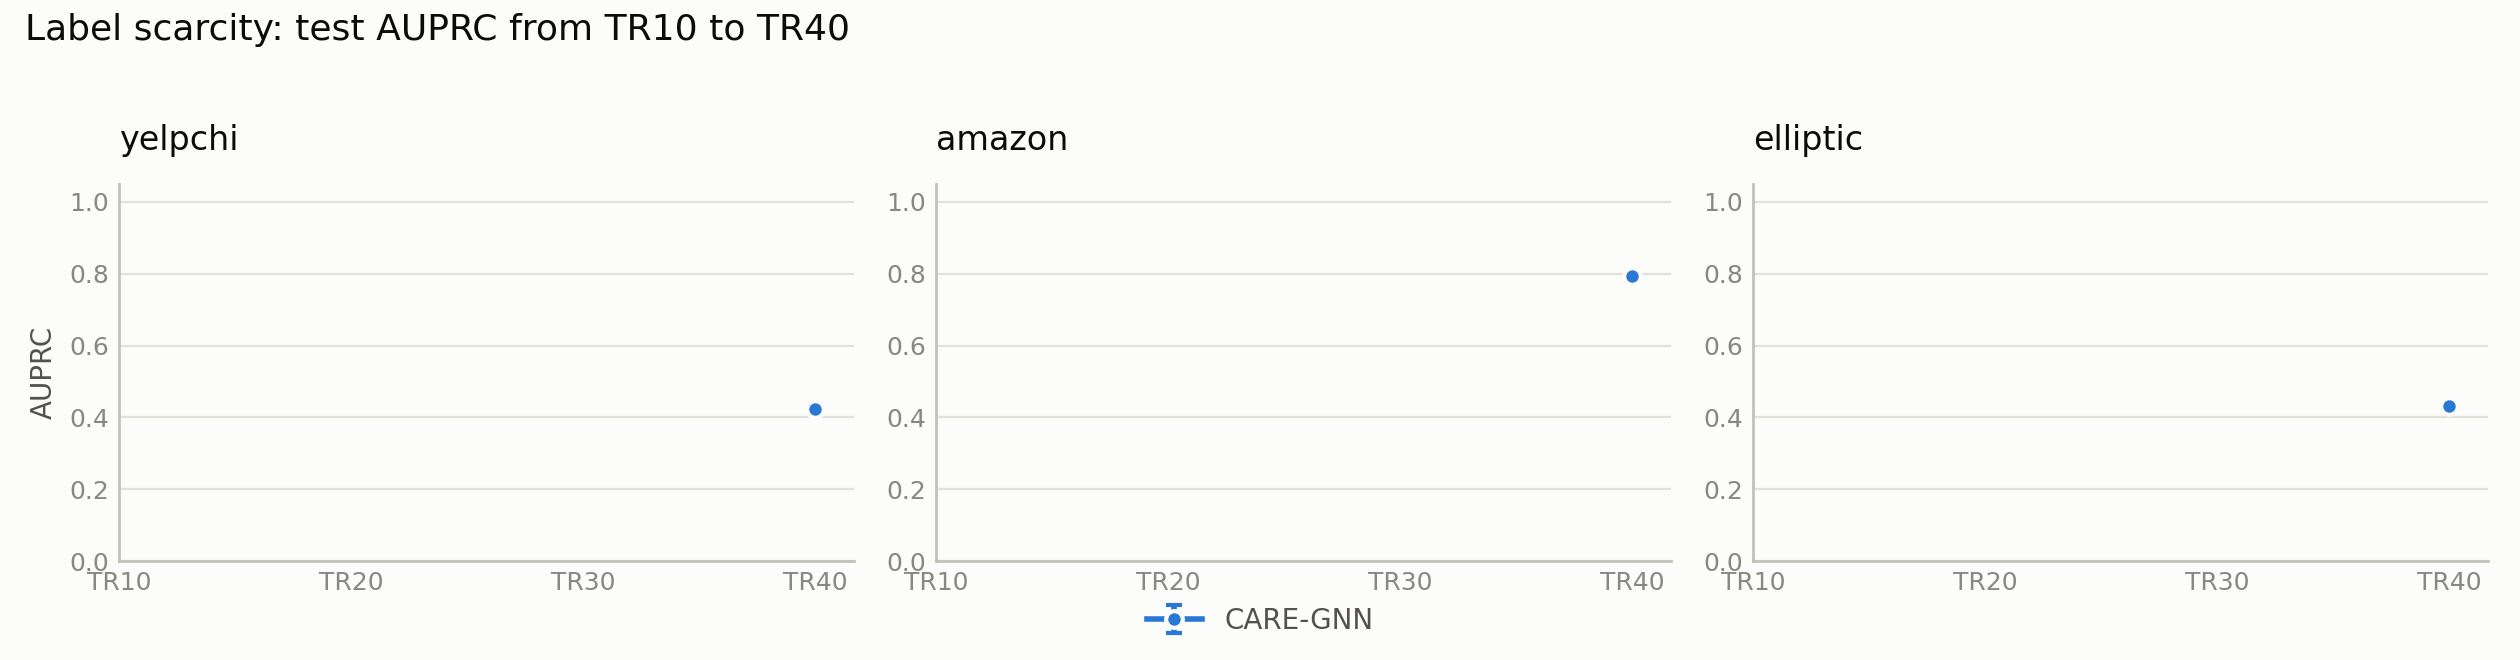

metric_heatmap_TR40.png


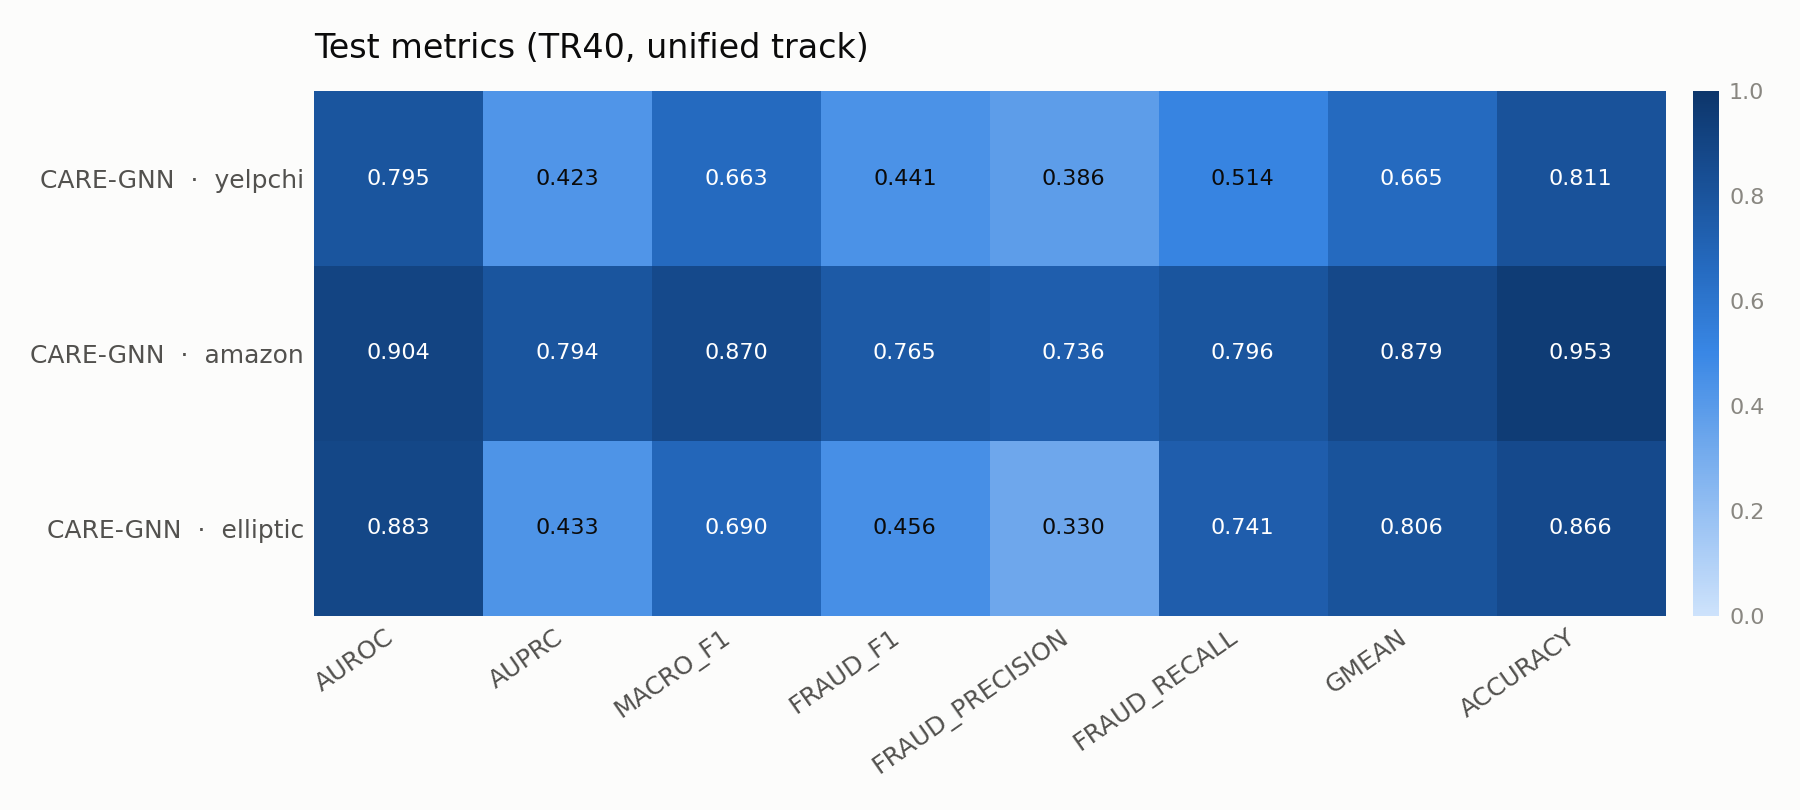

model_comparison_auprc_TR40.png


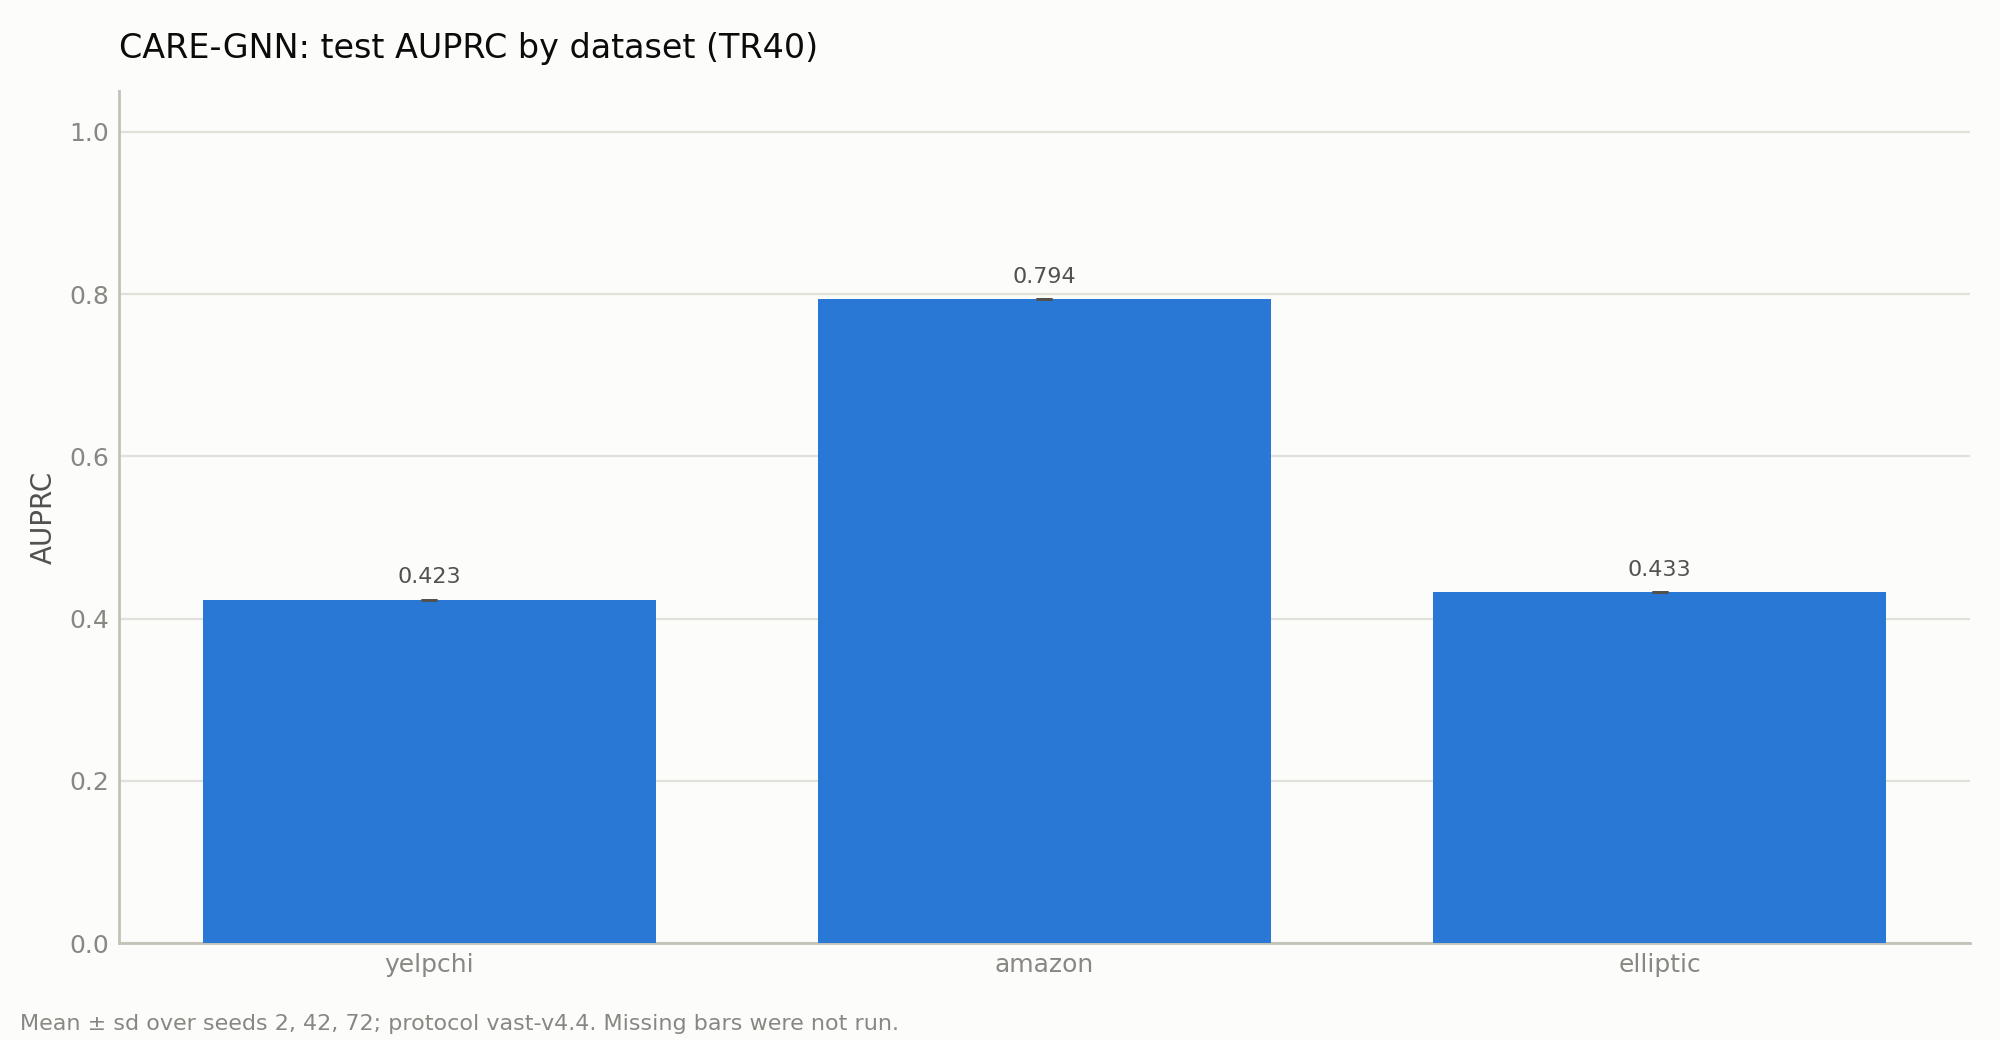

runtime_TR40.png


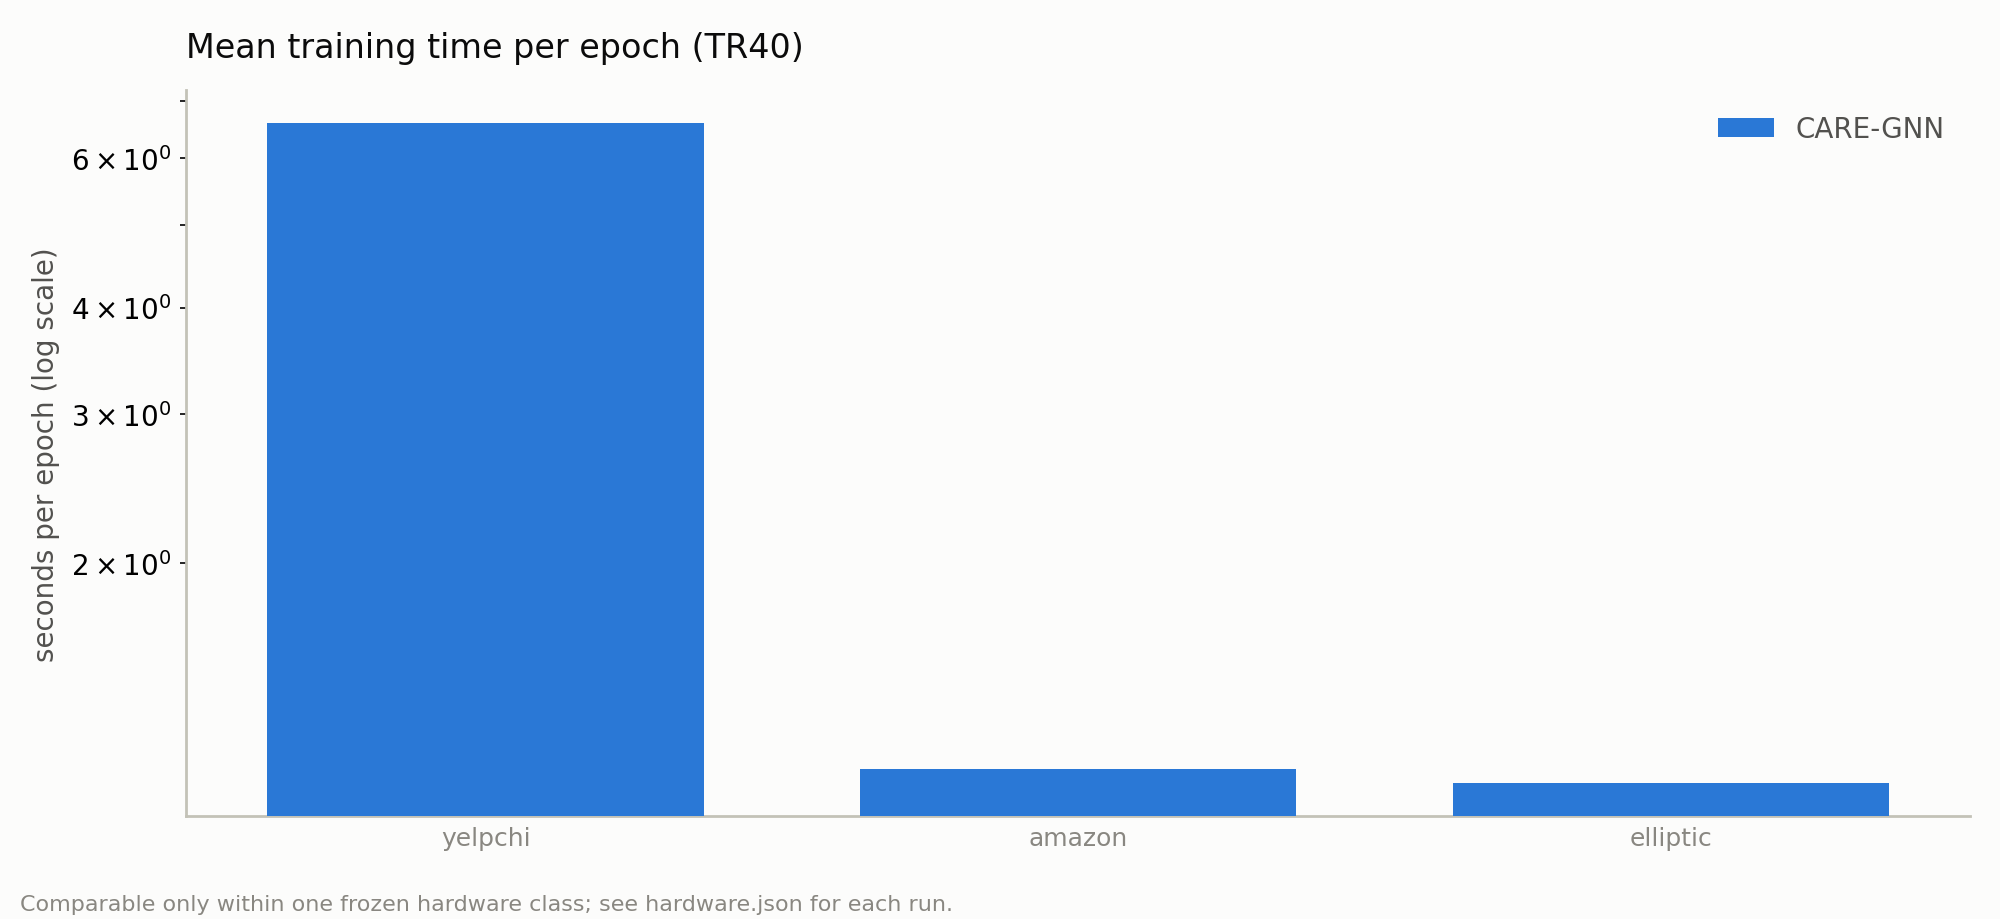

In [46]:
plots_dir = COMBINED / "plots"
for image in sorted(plots_dir.glob("*.png")) if plots_dir.exists() else []:
    print(image.name)
    display(Image(filename=str(image)))


In [47]:
stamp = time.strftime("%Y%m%dT%H%M%SZ", time.gmtime())
archive = shutil.make_archive(str(BASE / f"comp8851_combined_{stamp}"), "zip",
                              root_dir=str(COMBINED))
print(f"Combined archive: {archive}")
print(f"Size: {Path(archive).stat().st_size / 1024**2:.1f} MB")
print("\nFor the report:")
print("  reports/benchmark_summary.md   cross-model table")
print("  reports/benchmark_table.tex    LaTeX, paste straight in")
print("  reports/run_ledger.csv         every required cell and its status")
print("  plots/                         comparison figures")


Combined archive: /kaggle/working/compare/comp8851_combined_20260913T044333Z.zip
Size: 40.9 MB

For the report:
  reports/benchmark_summary.md   cross-model table
  reports/benchmark_table.tex    LaTeX, paste straight in
  reports/run_ledger.csv         every required cell and its status
  plots/                         comparison figures


## Reporting honestly

Two things to state plainly:

1. If either model ran in `FAST_MODE`, those results are **single-seed at TR40**.
   Do not present one seed as a mean across seeds.
2. Runtime is only comparable within one GPU class. If CARE-GNN ran on a Kaggle
   T4 and GHRN on a Vast.ai A6000, their predictive metrics still compare but
   their timings do not. `hardware.json` in each run records what it ran on.
